In [1]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.validation import make_valid

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_images = '/home/abhis/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-0prm_noccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap.csv')
scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-12prm_noccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-112_prm_no_ccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap_12_subprob.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

pier_prm_112_no_ccap_2040_1
pier_prm_112_no_ccap_2040_2
pier_prm_112_no_ccap_2040_3
pier_prm_112_no_ccap_2040_4
pier_prm_112_no_ccap_2040_5
pier_prm_112_no_ccap_2040_6
pier_prm_112_no_ccap_2040_7
pier_prm_112_no_ccap_2040_8
pier_prm_112_no_ccap_2040_9
pier_prm_112_no_ccap_2040_10
pier_prm_112_no_ccap_2040_11
pier_prm_112_no_ccap_2040_12
pier_prm_112_no_ccap_2040_13
pier_prm_112_no_ccap_2040_14
pier_prm_112_no_ccap_2040_15
pier_prm_112_no_ccap_2040_16
pier_prm_112_no_ccap_2040_17
pier_prm_112_no_ccap_2040_18
    timepoint          load_zone   static_load  net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  18479.474483 -5352.372034             0.0   
1  2040040101  Arunachal_Pradesh    329.816680   261.713331             0.0   
2  2040040101              Assam   4089.792284  2729.990137             0.0   
3  2040040101             Bhutan      0.000000 -3060.159527             0.0   
4  2040040101              Bihar   9839.340580  6541.317509             0.0   

   unserved_

In [3]:
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

# State-level metrics for all iterations (includes national metrics)

In [4]:
df = df_load_.copy()

# Exclude Bhutan
df = df[df['load_zone'] != "Bhutan"].copy()

HOURS_PER_YEAR = 8760.0  
tau = 1.0  # 1 MW threshold for LOL event

df['is_lol']     = df['unserved_energy'] > tau
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

def compute_metrics(sub, label):
    """Compute RA metrics for a given dataframe slice."""
    num_iters = sub[['W','H','A']].drop_duplicates().shape[0]
    hrs_run_total = float(sub['hrs_in_tmp'].sum())
    n_years = hrs_run_total / HOURS_PER_YEAR if hrs_run_total else np.nan

    total_lol_hours    = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())

    days_with_lol = int(
        sub.groupby(['W','H','A','date'])['is_lol'].max().sum()
    )

    # Annualized metrics
    EUE_MWh_per_yr   = (total_unserved_MWh / n_years) if np.isfinite(n_years) else np.nan
    LOLH_hrs_per_yr  = (total_lol_hours / n_years) if np.isfinite(n_years) else np.nan
    LOLE_days_per_yr = (days_with_lol / n_years) if np.isfinite(n_years) else np.nan

    return {
        'load_zone':               label,
        'iterations (W,H,A)':      num_iters,
        'LOLH (hrs/yr)':           LOLH_hrs_per_yr,
        'EUE (MWh/yr)':            EUE_MWh_per_yr,
        'LOLE (days/yr)':          LOLE_days_per_yr,
        'LOLE (days/10yr)':        (LOLE_days_per_yr * 10) if np.isfinite(LOLE_days_per_yr) else np.nan,
        'LOLP (fraction of hrs)':  (total_lol_hours / hrs_run_total) if hrs_run_total > 0 else np.nan,
        'LOLP (%)':                ((total_lol_hours / hrs_run_total) * 100) if hrs_run_total > 0 else np.nan,
        'Annual Energy (MWh/yr)':  (total_energy_MWh / n_years) if np.isfinite(n_years) else np.nan,
        'NENS (%)':                (100 * EUE_MWh_per_yr / (total_energy_MWh / n_years))
                                   if (n_years and total_energy_MWh > 0) else np.nan,
    }

# --- per-zone metrics ---
zone_metrics = []
for zone, sub in df.groupby("load_zone"):
    zone_metrics.append(compute_metrics(sub.copy(), zone))
metrics_df = pd.DataFrame(zone_metrics)

# --- national metric (all zones pooled) ---
national_metric_df = pd.DataFrame([
    compute_metrics(df.copy(), "National (excl. Bhutan)")
])

# --- outputs ---
print(metrics_df)

print(national_metric_df)


             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0       Andhra_Pradesh                  18       0.222222   1162.647217   
1    Arunachal_Pradesh                  18       0.000000      0.000000   
2                Assam                  18       0.000000      0.000000   
3                Bihar                  18       0.000000      0.000000   
4           Chandigarh                  18       8.722222    566.197106   
5         Chhattisgarh                  18       0.000000      0.000000   
6   Dadra_Nagar_Haveli                  18      35.500000  10122.473000   
7            Daman_Diu                  18       1.500000    243.896484   
8                Delhi                  18       1.500000   5998.512073   
9                  Goa                  18       3.833333    936.125167   
10             Gujarat                  18       1.222222   4344.274602   
11             Haryana                  18       0.000000      0.000000   
12    Himachal_Pradesh   

# States violating the global standards

In [5]:
# Filter zones with LOLP > 0.0274 OR LOLE > 1 day/10yr
filtered_metrics_global_df = metrics_df[
    (metrics_df['LOLP (%)'] > 0.0274) |
    (metrics_df['LOLE (days/10yr)'] > 1.0)
].reset_index(drop=True)

print("=== Zones with inadequate reliability ===")
print(filtered_metrics_global_df)


=== Zones with inadequate reliability ===
             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0       Andhra_Pradesh                  18       0.222222   1162.647217   
1           Chandigarh                  18       8.722222    566.197106   
2   Dadra_Nagar_Haveli                  18      35.500000  10122.473000   
3            Daman_Diu                  18       1.500000    243.896484   
4                Delhi                  18       1.500000   5998.512073   
5                  Goa                  18       3.833333    936.125167   
6              Gujarat                  18       1.222222   4344.274602   
7           Puducherry                  18       1.166667   1171.276263   
8               Punjab                  18       1.500000   9164.736620   
9            Telangana                  18       0.611111   4508.054249   
10         Uttarakhand                  18       0.222222     51.664108   

    LOLE (days/yr)  LOLE (days/10yr)  LOLP (fraction of h

# Reliability Assesment

## Processing state-level metrics for every interation (W, H, and A combinations)

In [6]:
df = df_load_.copy()

# --- flags & helpers ---
df['is_lol']     = df['unserved_energy'] > tau # 1MW threshold for LOL event
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

metrics, events_stats = [], []
group_cols = ['load_zone', 'W', 'H', 'A']
HOURS_PER_YEAR = 8760.0  

for (zone, w, h, a), sub in df.groupby(group_cols):
    hrs_run = sub['hrs_in_tmp'].sum()
    n_years = hrs_run / HOURS_PER_YEAR if hrs_run > 0 else np.nan

    # --- energy & tallies (MW → MWh by multiplying hrs_in_tmp) ---
    total_lol_hours   = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())
    days_with_lol      = int(sub.groupby('date')['is_lol'].max().sum())

    # --- annualized metrics ---
    LOLH   = total_lol_hours / n_years if np.isfinite(n_years) else np.nan
    EUE_MWh = total_unserved_MWh / n_years if np.isfinite(n_years) else np.nan
    EUE_GWh = EUE_MWh / 1000 if np.isfinite(EUE_MWh) else np.nan
    LOLE_10yr = (days_with_lol / n_years * 10) if np.isfinite(n_years) else np.nan
    LOLP   = total_lol_hours / hrs_run if hrs_run > 0 else np.nan
    annual_energy = total_energy_MWh / n_years if np.isfinite(n_years) else np.nan
    NENS   = 100 * EUE_MWh / annual_energy if (annual_energy and np.isfinite(annual_energy)) else np.nan

    metrics.append({
        'load_zone':        zone,
        'W':                w, 'H': h, 'A': a,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (GWh/yr)':     EUE_GWh,
        'LOLE (days/10yr)': LOLE_10yr,
        'LOLP (fraction)':  LOLP,
        'NENS (%)':         NENS
    })

    # --- event‐level stats ---
    run = sub.sort_values('timestamp').copy()
    run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
    run['event_id']    = run['event_start'].cumsum()

    durations = run[run['is_lol']].groupby('event_id').size()
    events_stats.append({
        'load_zone':              zone,
        'W': w, 'H': h, 'A': a,
        'num_LOL_events':         int(durations.count()),
        'total_LOL_duration_hrs': int(durations.sum())
    })

# Build DataFrames
metrics_per_zone_df = pd.DataFrame(metrics)
lol_events_df       = pd.DataFrame(events_stats)


print(lol_events_df)


          load_zone   W   H   A  num_LOL_events  total_LOL_duration_hrs
0    Andhra_Pradesh   1   1   1               0                       0
1    Andhra_Pradesh  10  10  10               0                       0
2    Andhra_Pradesh  11  11  11               2                       2
3    Andhra_Pradesh  12  12  12               0                       0
4    Andhra_Pradesh  13  13  13               0                       0
..              ...  ..  ..  ..             ...                     ...
625     West_Bengal   5   5   5               0                       0
626     West_Bengal   6   6   6               0                       0
627     West_Bengal   7   7   7               0                       0
628     West_Bengal   8   8   8               0                       0
629     West_Bengal   9   9   9               0                       0

[630 rows x 6 columns]


# Loss-of-load probability heatmap

In [7]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

print(LOLP_.max(), LOLP_.min())

     month  interval  lol
0        1         1    0
1        1         2    0
2        1         3    0
3        1         4    0
4        1         5    0
..     ...       ...  ...
283     12        20    9
284     12        21    5
285     12        22    3
286     12        23    0
287     12        24    0

[288 rows x 3 columns]
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
1 30
3 30
7 30
5 30
4 30
3 30
28 30
1 30
1 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
1 31
2 31
1 31
1 31
6 31
4 31
4 31
5 31
24 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
1 30
2 30
0 30
0 30
2 30
1 30
0 30
1 30
21 30
29 30
12 30
2 30
6 30
0 30
0 30
0 30
0 30
0 30
3 31
2 31
3 31
1 31
2 31
0 31
5 31
4 31
0 31
0 31
2 31
3 31
1 31
3 31
8 31
6 31
1 31
5 31
8 31
4 31
2 31
6 31
4 31
2 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
4 31
16 31
14 31
13 31
17 31
24 31
15 31
4 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
1 30
2 30
3 30
0 30
0 30
0 3

# Load and processing project timepoints

In [8]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'power_mw',
                           'capacity_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw',
                           'availability_derate']] # availability_derate

                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum',
                                                      'capacity_mw' : 'sum',
                                                      'availability_derate': 'mean'}).reset_index(drop = False)

                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh',
                                            'availability_derate': 'availability_factor'})

                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone',
                        'W','H','A']).agg({'power_mw': 'sum',
                                           'capacity_mw' : 'sum',
                                           'curtailment_mw': 'sum',
                                           'energy_mwh': 'sum',
                                           'charge_mw': 'sum',
                                           'discharge_mw': 'sum',
                                           'availability_factor': 'mean'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

pier_prm_112_no_ccap_2040_1
pier_prm_112_no_ccap_2040_2
pier_prm_112_no_ccap_2040_3
pier_prm_112_no_ccap_2040_4
pier_prm_112_no_ccap_2040_5
pier_prm_112_no_ccap_2040_6
pier_prm_112_no_ccap_2040_7
pier_prm_112_no_ccap_2040_8
pier_prm_112_no_ccap_2040_9
pier_prm_112_no_ccap_2040_10
pier_prm_112_no_ccap_2040_11
pier_prm_112_no_ccap_2040_12
pier_prm_112_no_ccap_2040_13
pier_prm_112_no_ccap_2040_14
pier_prm_112_no_ccap_2040_15
pier_prm_112_no_ccap_2040_16
pier_prm_112_no_ccap_2040_17
pier_prm_112_no_ccap_2040_18
    timepoint technology       load_zone   W   H   A    power_mw  capacity_mw  \
0  2040040101    Battery  Andhra_Pradesh   1   1   1     0.00000  6517.067343   
1  2040040101    Battery  Andhra_Pradesh  10  10  10     0.00000  6517.067343   
2  2040040101    Battery  Andhra_Pradesh  11  11  11     0.00000  6517.067343   
3  2040040101    Battery  Andhra_Pradesh  12  12  12 -6451.89667  6517.067343   
4  2040040101    Battery  Andhra_Pradesh  13  13  13     0.00000  6517.067343   



#import transmission

In [9]:
# Load and process transmission_timepoint.csv
def _processing_transmission_timepoints(scenarios_):
    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_timepoint for {scenario}")

                df_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory=False)
                df_ = df_[[
                    'timepoint',
                    'load_zone_from',
                    'load_zone_to',
                    'transmission_flow_mw',
                    'transmission_losses_lz_from',
                    'transmission_losses_lz_to'
                ]]
                df_ = df_.groupby(
                    ['timepoint', 'load_zone_from', 'load_zone_to']
                ).agg({
                    'transmission_flow_mw': 'sum',
                    'transmission_losses_lz_from': 'sum', 
                    'transmission_losses_lz_to': 'sum'
                }).reset_index()

                # Make flow non-negative (use absolute values)
                df_['transmission_flow_mw'] = df_['transmission_flow_mw'].abs()

                # Add iteration descriptors
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop=True)


# Load and process transmission_period.csv
def _processing_transmission_period(scenarios_):
    dfz_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_period for {scenario}")

                df_2 = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory=False)
                df_2 = df_2[['load_zone_from', 'load_zone_to', 'max_mw']]
                df_2 = df_2.groupby(
                    ['load_zone_from', 'load_zone_to']
                ).agg({'max_mw': 'sum'}).reset_index()

                # Add iteration descriptors
                df_2['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_2['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_2['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfz_.append(df_2)

    return pd.concat(dfz_).reset_index(drop=True)


def add_max_mw_to_timepoints(df_timepoints, df_period):
    """
    Left-join max_mw onto transmission timepoints using
    (load_zone_from, load_zone_to, W, H, A) as keys.
    """
    keys = ['load_zone_from', 'load_zone_to', 'W', 'H', 'A']

    # Ensure period table is unique per key; if not, sum max_mw across duplicates
    df_period_u = (
        df_period
        .groupby(keys, as_index=False, dropna=False)['max_mw']
        .sum()
    )

    # Left-join to keep all timepoints
    merged = df_timepoints.merge(
        df_period_u, on=keys, how='left', validate='many_to_one'
    )

    # Optional: if any routes didn’t find a match, set max_mw to 0 (or keep NaN)
    merged['max_mw'] = merged['max_mw'].fillna(0)

    return merged


# --- Run pipeline ---
df_transmission_timepoints = _processing_transmission_timepoints(scenarios_)
df_transmission_period    = _processing_transmission_period(scenarios_)
df_transmission_timepoints = add_max_mw_to_timepoints(
    df_transmission_timepoints, df_transmission_period
)

# Build zone-level table: sum absolute flow and max_mw of every line incident to a zone
_cols_ = ['timepoint', 'W', 'H', 'A', 'transmission_flow_mw', 'max_mw']

df_from = (
    df_transmission_timepoints[_cols_ + ['load_zone_from']]
    .rename(columns={'load_zone_from': 'load_zone'})
)

df_to = (
    df_transmission_timepoints[_cols_ + ['load_zone_to']]
    .rename(columns={'load_zone_to': 'load_zone'})
)

df_transmission_timepoints_zone = (
    pd.concat([df_from, df_to], ignore_index=True)
      .groupby(['timepoint', 'W', 'H', 'A', 'load_zone'], as_index=False)
      .agg({
          'transmission_flow_mw': 'sum',
          'max_mw': 'sum'
      })
      .rename(columns={
          'transmission_flow_mw': 'zone_transmission_flow_mw',
          'max_mw': 'zone_max_mw'
      })
)

# Add tx_cap_factor
df_transmission_timepoints_zone['tx_cap_factor'] = (
    df_transmission_timepoints_zone['zone_transmission_flow_mw'] /
    df_transmission_timepoints_zone['zone_max_mw'].replace({0: pd.NA})
)

# print(df_transmission_timepoints.head())
# print(df_transmission_timepoints_zone.head())

Processing transmission_timepoint for pier_prm_112_no_ccap_2040_1
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_2
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_3
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_4
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_5
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_6
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_7
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_8
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_9
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_10
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_11
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_12
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_13
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_14
Processing transmission_timepoint for pier_prm_112_no_ccap_2040_15
Proc

In [10]:
# Add timestamp to df_transmission_timepoints
tp = df_transmission_timepoints['timepoint'].astype(str)

# First 8 chars are YYYYMMDD, rest are hour index
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  # 1–24

df_transmission_timepoints['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)

# Reorder so timestamp is the first column
cols = df_transmission_timepoints.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_transmission_timepoints = df_transmission_timepoints[cols]


In [11]:
# add tiemstamp to df_dispatch_
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_dispatch_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_dispatch_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_dispatch_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_dispatch_ = df_dispatch_[cols]

#Calculation of Renewable Energy Drought

In [12]:
# Filter for Wind and Solar technologies
df_wind = df_dispatch_[df_dispatch_['technology'] == 'Wind']
df_solar = df_dispatch_[df_dispatch_['technology'] == 'Solar']

# Group and sum Wind power and capacity by load_zone and timestamp
wind_grouped = df_wind.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Group and sum Solar power and capacity by load_zone and timestamp
solar_grouped = df_solar.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Merge the grouped Wind and Solar DataFrames
merged_df = pd.merge(
    wind_grouped, 
    solar_grouped, 
    on=['load_zone', 'timestamp','W','H','A'], 
    how='outer', 
    suffixes=('_wind', '_solar')
)

# Sum the Wind and Solar power and capacity into new columns
merged_df['total_renewable_mwh'] = merged_df['power_mw_wind'] + merged_df['power_mw_solar']
merged_df['total_renewable_capacity_mw'] = merged_df['capacity_mw_wind'] + merged_df['capacity_mw_solar']

# Select the final columns - no need for additional grouping
renewable_dispatch = merged_df[['load_zone', 'timestamp', 'W','H','A','total_renewable_mwh', 'total_renewable_capacity_mw']]

# net_cf=renewable_dispatch.copy()
# net_cf['capacity_factor'] = net_cf['total_renewable_mwh'] / net_cf['total_renewable_capacity_mw']

# # filter only the solar hours i.e. 9 AM to 5 PM
# net_cf = net_cf[(net_cf['timestamp'].dt.hour >= 9) & (net_cf['timestamp'].dt.hour < 17)]

# # keep the values whose capacity factor is below 0.025
# net_cf = net_cf[net_cf['capacity_factor'] < 0.025]


# calculation by average Plant load factor method

In [13]:

plf_df = renewable_dispatch.copy()

window_days = 2  

# Convert timestamp to plain date (YYYY-MM-DD)
plf_df['date'] = plf_df['timestamp'].dt.date  

# Aggregate to daily total generation and capacity
daily_df = (
    plf_df.groupby(['load_zone','W','H','A','date'], as_index=False)
          [['total_renewable_mwh','total_renewable_capacity_mw']].sum()
)

# Daily PLF
daily_df['daily_plf'] = (
    daily_df['total_renewable_mwh'] / daily_df['total_renewable_capacity_mw']
)

# Rolling PLF over 2 days
daily_df['plf'] = (
    daily_df.groupby(['load_zone','W','H','A'])['daily_plf']
            .transform(lambda x: x.rolling(window=window_days, min_periods=1).mean())
)

# Final dataframe (date-only, no hh:mm)
plf_df = daily_df.drop(columns=['daily_plf'])


In [14]:
# df_dispatch_ must have: timepoint, technology, load_zone, power_mw, capacity_mw, W, H, A

# 1) Correct timestamp (timepoints encoded as YYYYMMDDHH with HH=1..24)
tp = df_dispatch_['timepoint'].astype(str)
dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
hours = tp.str[8:].astype(int)  # 1..24
df_dispatch_ = df_dispatch_.copy()
df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')  # <-- fix at source

# 2) Wind & Solar hourly (sum if multiples)
keys = ['load_zone','timestamp','W','H','A']
cols = keys + ['power_mw','capacity_mw','technology']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']), cols].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

# 3) Merge wind+solar, fill zeros BEFORE summing
merged = (pd.merge(wind, solar, on=keys, how='outer')
            .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                     'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))

merged['total_power_mw']    = merged['power_mw_wind']    + merged['power_mw_solar']
merged['total_capacity_mw'] = merged['capacity_mw_wind'] + merged['capacity_mw_solar']

# 4) Day assignment (NO extra 1h shift now that timestamp is fixed)
merged['date'] = merged['timestamp'].dt.normalize()

# 5) Daily PLF and 48h (2-day) rolling PLF
daily = (merged.groupby(['load_zone','W','H','A','date'], as_index=False)
         .agg(energy_mwh_day=('total_power_mw','sum'),
              cap_hour_sum_day=('total_capacity_mw','sum')))

daily['plf_day'] = np.where(
    daily['cap_hour_sum_day'] > 0,
    daily['energy_mwh_day'] / daily['cap_hour_sum_day'],
    np.nan
)

window_days = 2  # 48 hours
daily = daily.sort_values(['load_zone','W','H','A','date'])
daily['plf'] = (daily.groupby(['load_zone','W','H','A'])['plf_day']
                .transform(lambda s: s.rolling(window=window_days, min_periods=1).mean()))

# 6) Final day-wise PLF dataframe + flag
plf_df = daily[['load_zone','W','H','A','date','plf']].copy()
plf_threshold = 0.025
plf_df['low_plf_flag'] = np.where(plf_df['plf'].notna() & (plf_df['plf'] < plf_threshold), 1, 0).astype('int8')

# 7) Enforce fiscal year window: Apr 1 → Mar 31 (change fy as needed)
fy = 2040  # FY 2040–41
fy_start = pd.Timestamp(f"{fy}-04-01")
fy_end   = pd.Timestamp(f"{fy+1}-03-31")

plf_df = plf_df[(plf_df['date'] >= fy_start) & (plf_df['date'] <= fy_end)].copy()
plf_df = plf_df.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)


#Calculation of top net demand days 

In [15]:
TOP_K = 5
FY = None           # e.g., 2040 for FY 2040–41 (Apr 1 → Mar 31), or None to skip

# Helper: correct timestamp from timepoint with hours 1..24
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

# 1) Ensure aligned timestamps on load & dispatch
df_load_ = df_load_.copy()
if 'timestamp' not in df_load_.columns:
    df_load_['timestamp'] = _timestamp_from_timepoint(df_load_)
df_load_['date'] = df_load_['timestamp'].dt.normalize()

df_dispatch_ = df_dispatch_.copy()
if 'timestamp' not in df_dispatch_.columns:
    df_dispatch_['timestamp'] = _timestamp_from_timepoint(df_dispatch_)

# 2) Build hourly RE total (Wind + Solar) per zone/W/H/A/timestamp
keys = ['load_zone','timestamp','W','H','A']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']),
                      keys + ['power_mw','capacity_mw','technology']].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

re_merged = (pd.merge(wind, solar, on=keys, how='outer')
               .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                        'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))
re_merged['total_re_mw'] = re_merged['power_mw_wind'] + re_merged['power_mw_solar']

# 3) Build netload_df = static_load − total_re_mw (hourly, PER ZONE)
netload_df = pd.merge(
    df_load_[keys + ['static_load']],
    re_merged[keys + ['total_re_mw']],
    on=keys, how='left'
).fillna({'total_re_mw': 0.0})

netload_df['net_load_mw'] = netload_df['static_load'] - netload_df['total_re_mw']
netload_df['date'] = netload_df['timestamp'].dt.normalize()

# (optional) restrict to fiscal year Apr 1 → Mar 31
if FY is not None:
    fy_start = pd.Timestamp(f"{FY}-04-01")
    fy_end   = pd.Timestamp(f"{FY+1}-03-31")
    netload_df = netload_df[(netload_df['date'] >= fy_start) & (netload_df['date'] <= fy_end)].copy()

# 4) Per-zone hourly net load (sum only in case of duplicates)
zone_hourly = (netload_df.groupby(['load_zone','W','H','A','timestamp'], as_index=False)['net_load_mw'].sum())
zone_hourly['date'] = zone_hourly['timestamp'].dt.normalize()

# 5) Per-zone DAILY PEAK net load (MW)
daily_peak_zone = (
    zone_hourly.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
               .max()
               .rename(columns={'net_load_mw':'daily_peak_net_load_mw'})
)

# 6) Top 5 days per (load_zone, W, H, A)
top5_zone_netload_days = (
    daily_peak_zone.sort_values(['load_zone','W','H','A','daily_peak_net_load_mw'],
                                ascending=[True, True, True, True, False])
                    .groupby(['load_zone','W','H','A'])
                    .head(TOP_K)
                    .reset_index(drop=True)
)

# (nice to have) rank within each zone+iteration
top5_zone_netload_days['rank'] = (
    top5_zone_netload_days.groupby(['load_zone','W','H','A'])['daily_peak_net_load_mw']
                          .rank(ascending=False, method='first').astype(int)
)

# make date a pure date object (no hh:mm:ss)
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# - netload_df: hourly net load by zone/W/H/A
# - top5_zone_netload_days: top 5 daily-peak net-load days for each (load_zone, W, H, A)


In [16]:
# Merging netyload with plf
# Make dates comparable (no hh:mm)
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# Align dtypes on join keys
for c in ['load_zone','W','H','A']:
    plf_df[c] = plf_df[c].astype(str)
    top5_zone_netload_days[c] = top5_zone_netload_days[c].astype(str)

# Keys
keys = ['load_zone','W','H','A','date']

# Build the flag from the top-5 table
top5_keys = top5_zone_netload_days[keys].drop_duplicates().assign(net_load=1)

# Merge into plf_df; fill others as 0
plf_df = (
    plf_df.drop(columns=['net_load'], errors='ignore')
          .merge(top5_keys, on=keys, how='left')
)
plf_df['net_load'] = plf_df['net_load'].fillna(0).astype('int8')

In [17]:
# Adding unserved energy to plf
# --- make dates comparable (no hh:mm) ---
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date

df_ls = df_load_.copy()

# If df_load_ doesn't already have the fixed timestamp (1..24 → hours-1), build it:
if 'timestamp' not in df_ls.columns:
    tp = df_ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    df_ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

df_ls['date'] = df_ls['timestamp'].dt.date

# --- build daily presence flag for load shedding (>0) per zone & W,H,A ---
keys = ['load_zone','W','H','A','date']
ls_presence = (
    df_ls.loc[df_ls['unserved_energy'] > 0, keys]
         .drop_duplicates()
         .assign(load_shedding=1)
)

# align dtypes on join keys (avoid int/str mismatches)
for k in ['load_zone','W','H','A']:
    plf_df[k]      = plf_df[k].astype(str)
    ls_presence[k] = ls_presence[k].astype(str)

# --- merge into plf_df; fill others as 0 ---
plf_df = (
    plf_df.drop(columns=['load_shedding'], errors='ignore')
          .merge(ls_presence, on=keys, how='left')
)
plf_df['load_shedding'] = plf_df['load_shedding'].fillna(0).astype('int8')


# Dataframe with weather indices and impact on LOL

In [18]:

# ---- keys we’ll reuse ----
keys4 = ['load_zone','W','H','A']

# start from plf_df
final_df = plf_df.copy()
final_df['date'] = pd.to_datetime(final_df['date']).dt.normalize()

# =========================
# 1) Expected EUE per (zone, W, H, A) and daily load shedding
# =========================
ls = df_load_.copy()

# ensure a correct hourly timestamp (1..24 encoded hours → hours-1)
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

ls['date'] = ls['timestamp'].dt.normalize()

# (optional but helps keep “one year” aligned with plf_df’s span)
ls = ls.merge(final_df[keys4].drop_duplicates(), on=keys4, how='inner')
ls = ls[(ls['date'] >= final_df['date'].min()) & (ls['date'] <= final_df['date'].max())]

# daily unserved energy per zone & iteration (assumes hourly steps → sum(MW)=MWh)
ls_daily = (
    ls.groupby(keys4 + ['date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy': 'load_shedding_mwh'})
)

# expected EUE over the year window (per zone & iteration)
expected_eue = (
    ls_daily.groupby(keys4, as_index=False)['load_shedding_mwh']
            .sum()
            .rename(columns={'load_shedding_mwh':'expected_eue_mwh'})
)

# merge into final_df
final_df = final_df.merge(ls_daily, on=keys4 + ['date'], how='left')
final_df['load_shedding_mwh'] = final_df['load_shedding_mwh'].fillna(0)

final_df = final_df.merge(expected_eue, on=keys4, how='left')
final_df['expected_eue_mwh'] = final_df['expected_eue_mwh'].fillna(0)

# ratio: daily load shedding as a share of expected EUE
final_df['load_shedding_eue'] = np.where(
    final_df['expected_eue_mwh'] > 0,
    final_df['load_shedding_mwh'] / final_df['expected_eue_mwh'],
    np.nan
)

# =========================
# 2) Ratio to maximum of top net load
# =========================
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()

# daily PEAK net load (MW)
nl_daily_peak = (
    nl.groupby(keys4 + ['date'], as_index=False)['net_load_mw']
      .max()
      .rename(columns={'net_load_mw':'daily_peak_netload_mw'})
)

# max of the top-5 daily peaks per (zone, W, H, A)
top5_max = (
    nl_daily_peak.sort_values(keys4 + ['daily_peak_netload_mw'],
                              ascending=[True, True, True, True, False])
                 .groupby(keys4, as_index=False).head(5)
                 .groupby(keys4, as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'})
)

# merge denom and compute ratio
final_df = final_df.merge(top5_max, on=keys4, how='left')
final_df['load_shedding_top_net_load'] = np.where(
    final_df['top_netload_max_mw'] > 0,
    final_df['load_shedding_mwh'] / final_df['top_netload_max_mw'],
    np.nan
)

# date as plain date (no time)
final_df['date'] = final_df['date'].dt.date


# Heatmap of Renewable Energy Drought days

In [19]:


selected_zone = "Karnataka"  # ← change here to switch zones
freq = "D"               # "D" daily; e.g., "W-MON" for weekly display
plt.rcParams.update({"font.family": "Arial", "font.size": 10})


def build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq="D"):
    # ---- Ensure df_dispatch_ has correct timestamp (1..24 → hours-1) ----
    if 'timestamp' not in df_dispatch_.columns:
        tp    = df_dispatch_['timepoint'].astype(str)
        dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
        hours = tp.str[8:].astype(int)
        df_dispatch_ = df_dispatch_.copy()
        df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')

    # ---- PLF-side (zone slice) ----
    z = plf_df.loc[
        plf_df['load_zone'] == selected_zone,
        ['W','H','A','date','plf','low_plf_flag','net_load','load_shedding']
    ].copy()
    if z.empty:
        raise ValueError(f"No PLF rows for '{selected_zone}'. "
                         f"Available: {sorted(plf_df['load_zone'].unique())}")
    z['date'] = pd.to_datetime(z['date']).dt.normalize()
    z[['W','H','A']] = z[['W','H','A']].astype(str)
    it_plf = z[['W','H','A']].drop_duplicates()

    # ---- TX-side (zone slice) ----
    tx = df_transmission_timepoints_zone.loc[
        df_transmission_timepoints_zone['load_zone'] == selected_zone,
        ['timepoint','W','H','A','load_zone','tx_cap_factor']
    ].copy()
    if tx.empty:
        tx_daily = pd.DataFrame(columns=['W','H','A','date','tx_cap_factor'])
        it_tx = pd.DataFrame(columns=['W','H','A'])
    else:
        if 'timestamp' not in tx.columns:
            tp    = tx['timepoint'].astype(str)
            dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
            hours = tp.str[8:].astype(int)
            tx['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')
        tx['date'] = tx['timestamp'].dt.normalize()
        tx[['W','H','A']] = tx[['W','H','A']].astype(str)
        tx_daily = tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].mean()
        it_tx = tx_daily[['W','H','A']].drop_duplicates()

    # ---- Combined Availability Factor (Coal/Gas/CCGT/CT/Nuclear/Biomass) ----
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    disp = df_dispatch_.loc[
        (df_dispatch_['load_zone'] == selected_zone) &
        (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
        ['load_zone','timestamp','W','H','A','technology','power_mw','capacity_mw'] +
        ([c for c in ['availability_derate','availability_factor'] if c in df_dispatch_.columns])
    ].copy()
    disp['date'] = disp['timestamp'].dt.normalize()
    disp[['W','H','A']] = disp[['W','H','A']].astype(str)

    if 'availability_derate' in disp.columns:
        disp['af_src'] = disp['availability_derate']
    elif 'availability_factor' in disp.columns:
        disp['af_src'] = disp['availability_factor']
    else:
        disp['af_src'] = np.where(
            disp['capacity_mw'] > 0,
            (disp['power_mw'] / disp['capacity_mw']).clip(0, 1),
            np.nan
        )

    keys_ts = ['load_zone','timestamp','W','H','A']
    caf_ts = (disp.assign(weighted=disp['capacity_mw'] * disp['af_src'])
                    .groupby(keys_ts, as_index=False)
                    .agg(caf_num=('weighted','sum'),
                         caf_den=('capacity_mw','sum')))
    caf_ts['caf'] = np.where(caf_ts['caf_den'] > 0, caf_ts['caf_num'] / caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    caf_daily = caf_ts.groupby(['W','H','A','date'], as_index=False)['caf'].mean()
    it_caf = caf_daily[['W','H','A']].drop_duplicates()

    # ---- Master iteration list = union(PLF, TX, CAF) ----
    it_master = (pd.concat([it_plf, it_tx, it_caf], ignore_index=True)
                   .drop_duplicates()
                   .sort_values(['W','H','A'])
                   .reset_index(drop=True))
    it_master['iteration'] = np.arange(1, len(it_master) + 1)

    # Attach iteration ids
    z = z.merge(it_master, on=['W','H','A'], how='left')
    caf_daily = caf_daily.merge(it_master, on=['W','H','A'], how='left')

    # ---- Pivot PLF matrices and resample ----
    heat = (z.pivot_table(index='iteration', columns='date', values='plf',          aggfunc='mean')
              .T.resample(freq).mean().T)
    flag = (z.pivot_table(index='iteration', columns='date', values='low_plf_flag', aggfunc='max' )
              .T.resample(freq).max().T)
    net  = (z.pivot_table(index='iteration', columns='date', values='net_load',     aggfunc='max' )
              .T.resample(freq).max().T)
    shed = (z.pivot_table(index='iteration', columns='date', values='load_shedding',aggfunc='max' )
              .T.resample(freq).max().T)

    # Full date axis across PLF, TX, CAF
    plf_cols = heat.columns if heat.shape[1] else pd.Index([])
    tx_cols  = pd.to_datetime(tx_daily['date']).sort_values().unique() if len(tx_daily) else pd.Index([])
    caf_cols = pd.to_datetime(caf_daily['date']).sort_values().unique() if len(caf_daily) else pd.Index([])
    cols_all = [c for c in [plf_cols, tx_cols, caf_cols] if len(c)]
    if cols_all:
        full_start = min(c.min() for c in cols_all)
        full_end   = max(c.max() for c in cols_all)
    else:
        raise ValueError(f"No dates found for '{selected_zone}'.")

    full_cols = pd.date_range(pd.to_datetime(full_start), pd.to_datetime(full_end), freq=freq)

    # Reindex PLF mats to master iters & full date axis
    heat = heat.reindex(index=it_master['iteration'].to_numpy(), columns=full_cols)
    flag = flag.reindex(index=heat.index, columns=heat.columns, fill_value=0)
    net  = net .reindex(index=heat.index, columns=heat.columns, fill_value=0)
    shed = shed.reindex(index=heat.index, columns=heat.columns, fill_value=0)

    # TX & CAF to same grid
    if len(tx_daily):
        tx_daily = tx_daily.merge(it_master, on=['W','H','A'], how='left')
        tx_mat = (tx_daily.pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='mean')
                            .T.resample(freq).mean().T)
        tx_mat = tx_mat.reindex(index=heat.index, columns=heat.columns)
    else:
        tx_mat = pd.DataFrame(index=heat.index, columns=heat.columns, data=np.nan)
    if len(caf_daily):
        caf_mat = (caf_daily.pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                             .T.resample(freq).mean().T)
        caf_mat = caf_mat.reindex(index=heat.index, columns=heat.columns)
    else:
        caf_mat = pd.DataFrame(index=heat.index, columns=heat.columns, data=np.nan)

    # Rotate so x-axis starts at January
    cols_dt = pd.to_datetime(heat.columns)
    jan_idx = np.where(cols_dt.month == 1)[0]
    if len(jan_idx) > 0:
        start = jan_idx[0]
        order = np.r_[start:len(cols_dt), 0:start]
        heat   = heat.iloc[:, order]
        flag   = flag.iloc[:, order]
        net    = net .iloc[:, order]
        shed   = shed.iloc[:, order]
        caf_mat= caf_mat.iloc[:, order]
        tx_mat = tx_mat.iloc[:, order]
        cols_dt = cols_dt[order]

    # Month ticks & labels
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]
    month_labels = cols_dt[month_starts].strftime('%b')

    return it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels


In [20]:
def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No diagonal (W==H==A) iterations found in plf_df for '{selected_zone}'.")

    # --- Daily LoL (zone) ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, fy)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load-shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary 0/1)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates)
                 .fillna(0).astype('int8'))

    # === LoL % = (sum UE on LoL hours) / (sum static load on SAME hours) × 100 ===
    load_zone = load[load['load_zone'] == selected_zone].copy()
    lol_hours = load_zone[load_zone['unserved_energy'] > 0].copy()  # only hours with LoL
    lol_ratio_day = (lol_hours.groupby(['W','H','A','date'], as_index=False)
                               .agg(ue=('unserved_energy','sum'),
                                    demand=('static_load','sum')))
    lol_ratio_day['lol_ratio_pct'] = np.where(
        lol_ratio_day['demand'] > 0, 100.0 * lol_ratio_day['ue'] / lol_ratio_day['demand'], np.nan
    )
    LoL_ratio_pct = (iters.merge(lol_ratio_day[['W','H','A','date','lol_ratio_pct']], on=['W','H','A'], how='left')
                          .pivot_table(index='iteration', columns='date', values='lol_ratio_pct', aggfunc='sum')
                          .reindex(index=iters['iteration'], columns=lol_dates))
    LoL_ratio_pct = LoL_ratio_pct.where(LoL==1)

    # --- NEW: Daily LOAD (MWh) ---
    daily_load = (load_zone.groupby(['W','H','A','date'], as_index=False)['static_load']
                             .sum().rename(columns={'static_load':'daily_load_mwh'}))
    LOAD_MWh = (iters.merge(daily_load, on=['W','H','A'], how='left')
                      .pivot_table(index='iteration', columns='date', values='daily_load_mwh', aggfunc='sum')
                      .reindex(index=iters['iteration'], columns=lol_dates))
    LOAD_MWh = LOAD_MWh.where(LoL==1)

    # --- NEW: Daily NET LOAD (MWh = load − unserved) ---
    daily_netload = (load_zone.groupby(['W','H','A','date'], as_index=False)
                               .apply(lambda x: (x['static_load'] - x['unserved_energy']).sum())
                               .reset_index().rename(columns={0:'daily_netload_mwh'}))
    NET_LOAD_MWh = (iters.merge(daily_netload, on=['W','H','A'], how='left')
                          .pivot_table(index='iteration', columns='date', values='daily_netload_mwh', aggfunc='sum')
                          .reindex(index=iters['iteration'], columns=lol_dates))
    NET_LOAD_MWh = NET_LOAD_MWh.where(LoL==1)

    # (rest of your RE_CF_pct, CAF_pct, TX_pct, PEAK_pct code unchanged...)

    cols_dt = pd.to_datetime(lol_dates)

    # --- return with two extra matrices ---
    return iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt, LOAD_MWh, NET_LOAD_MWh

# state level plots

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

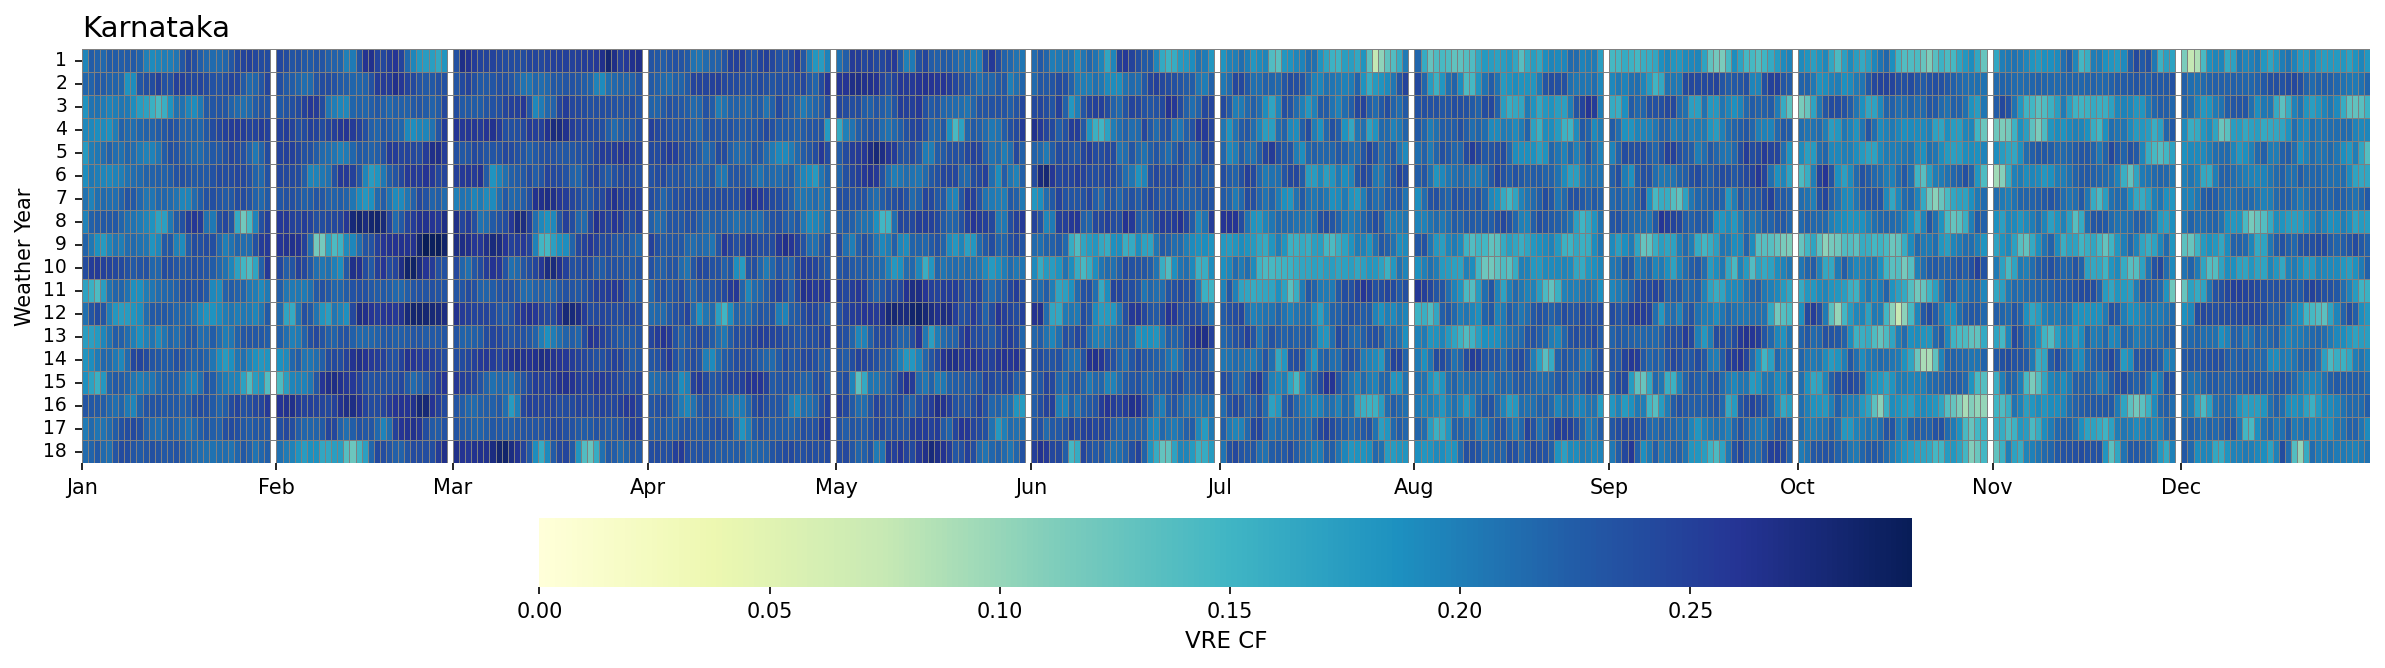

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

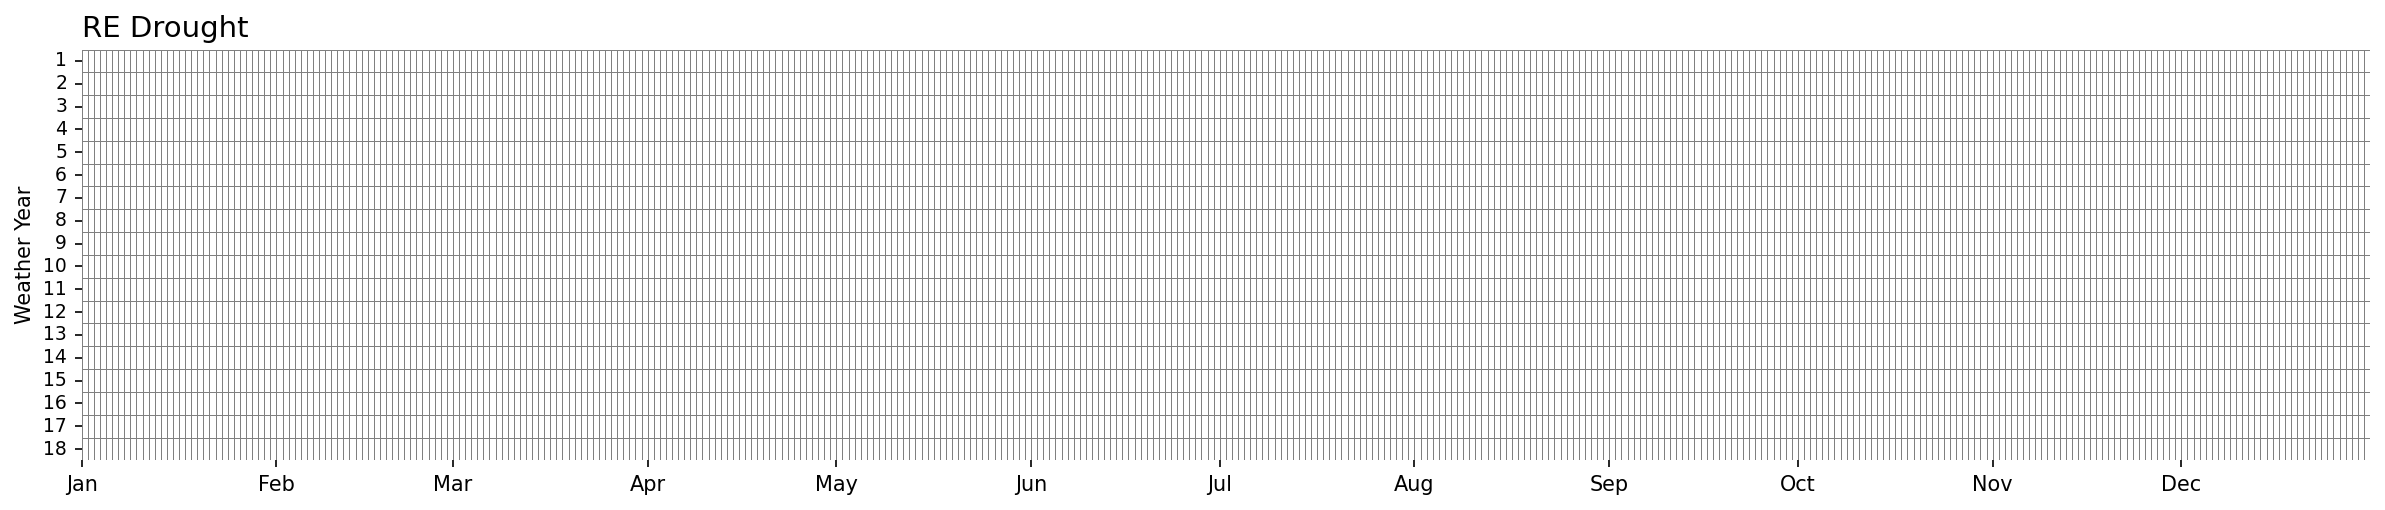

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

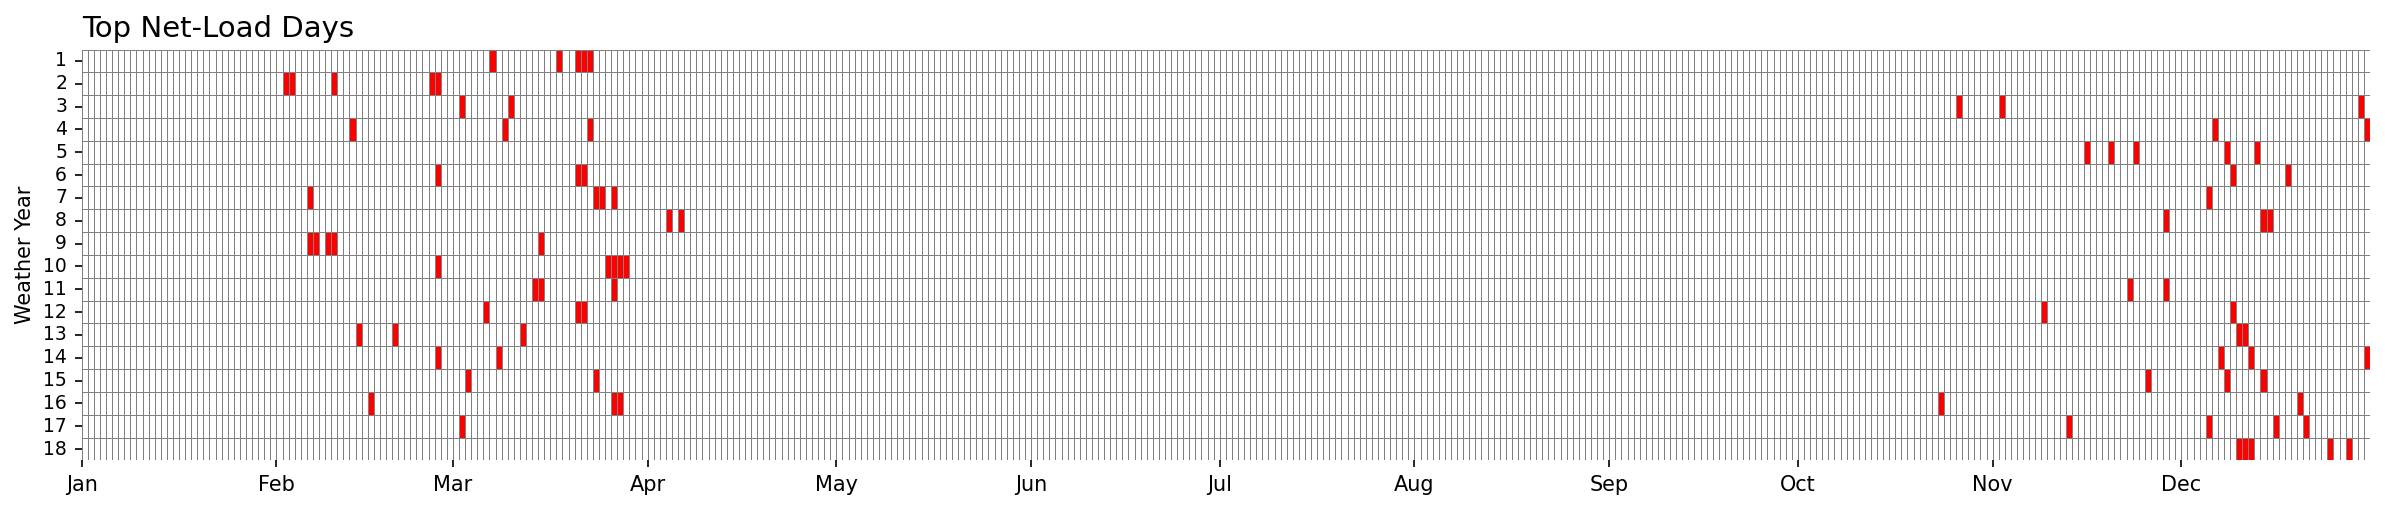

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

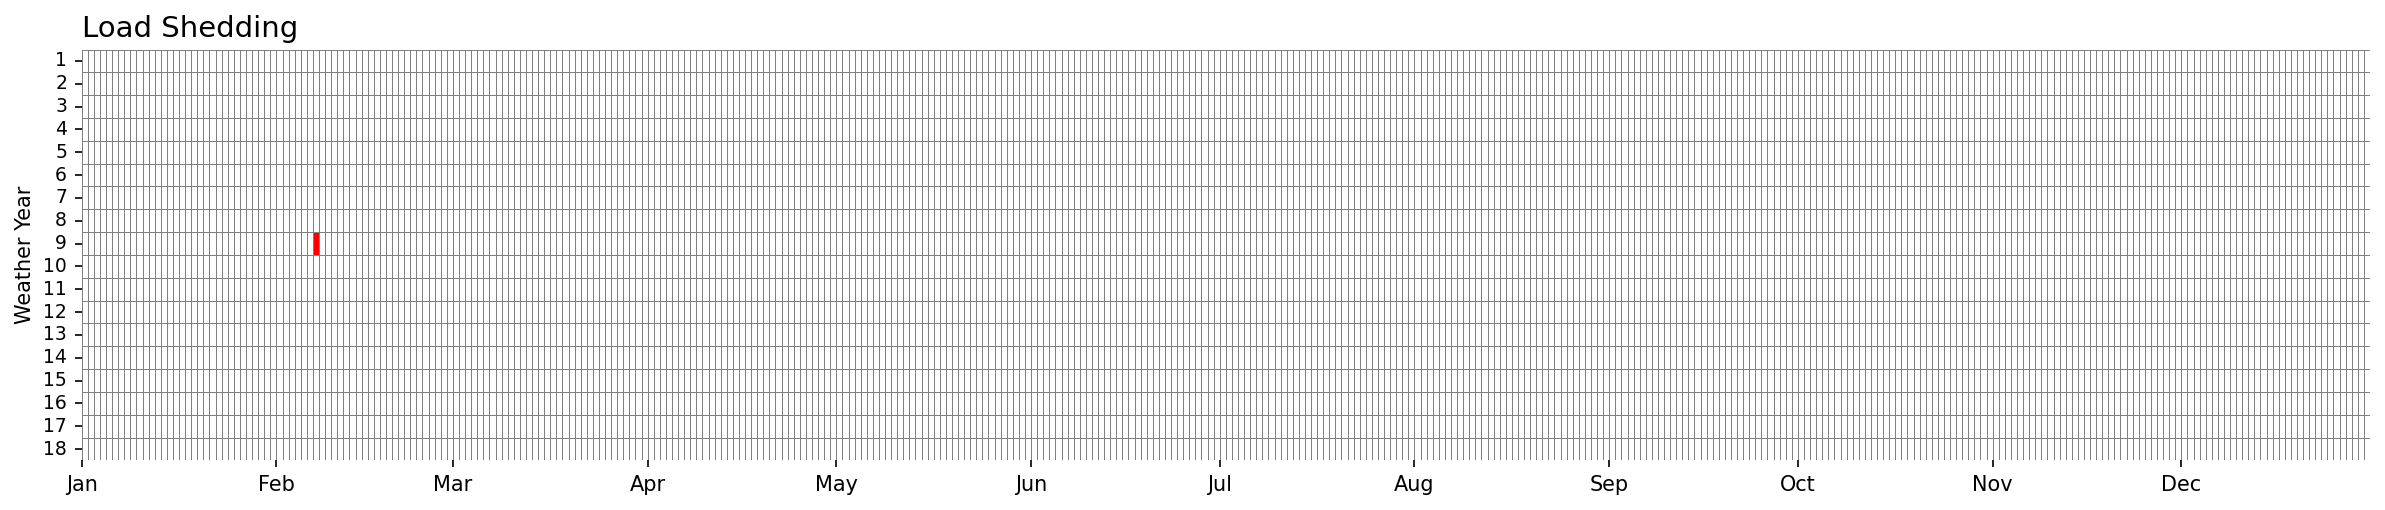

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

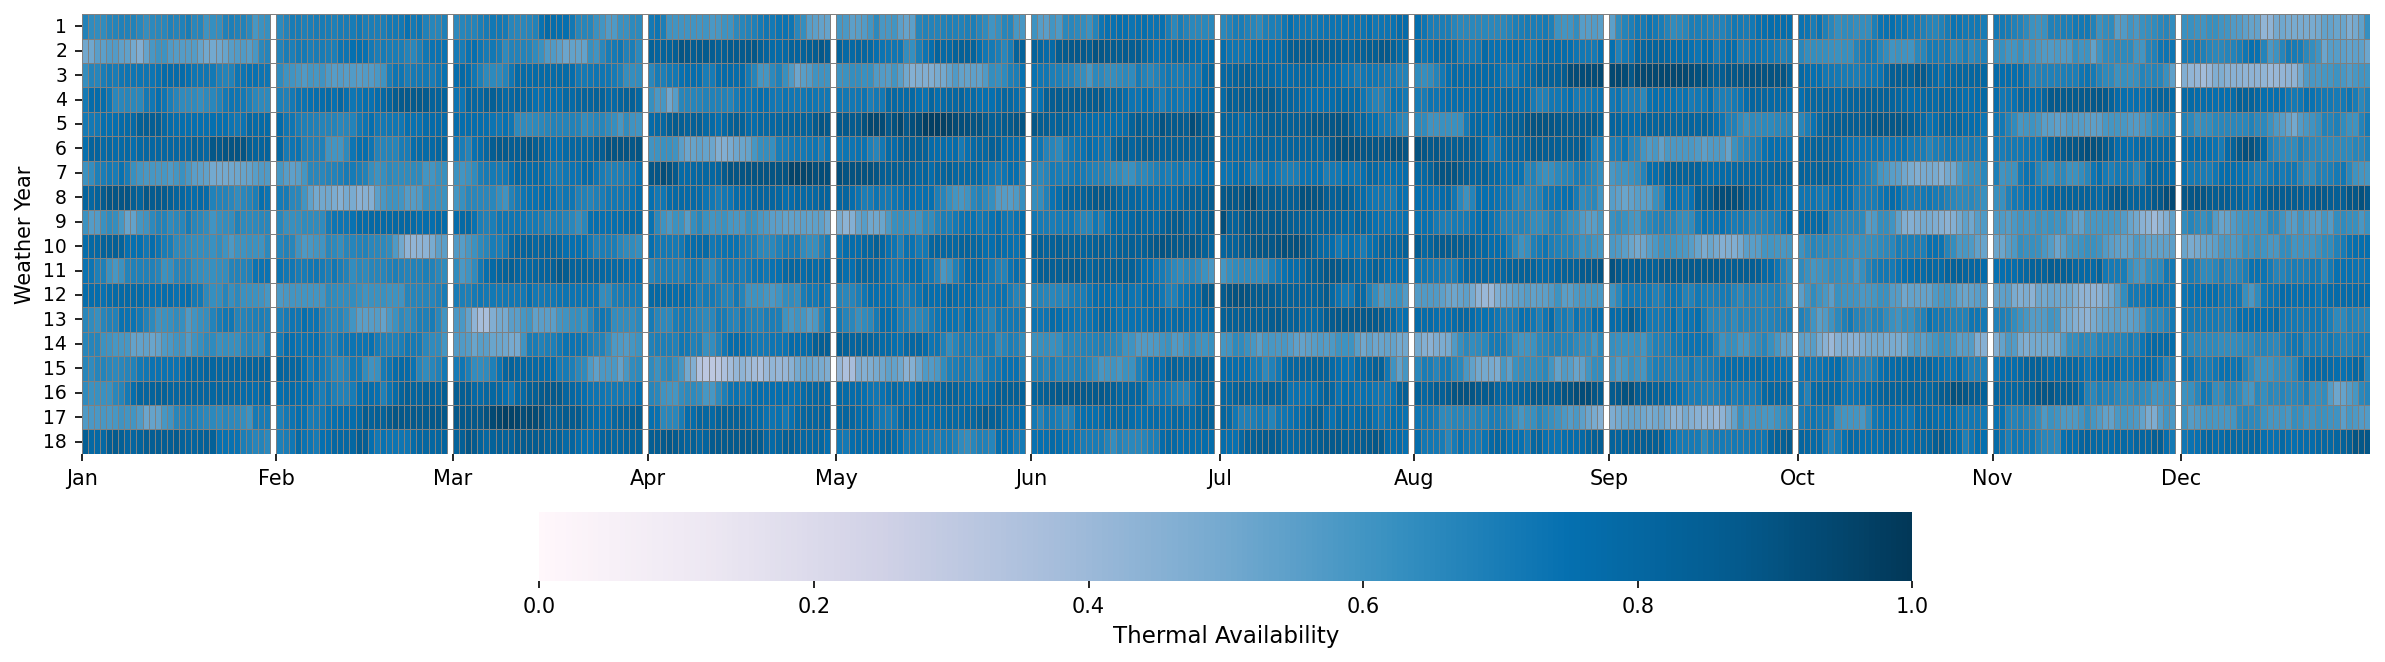

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

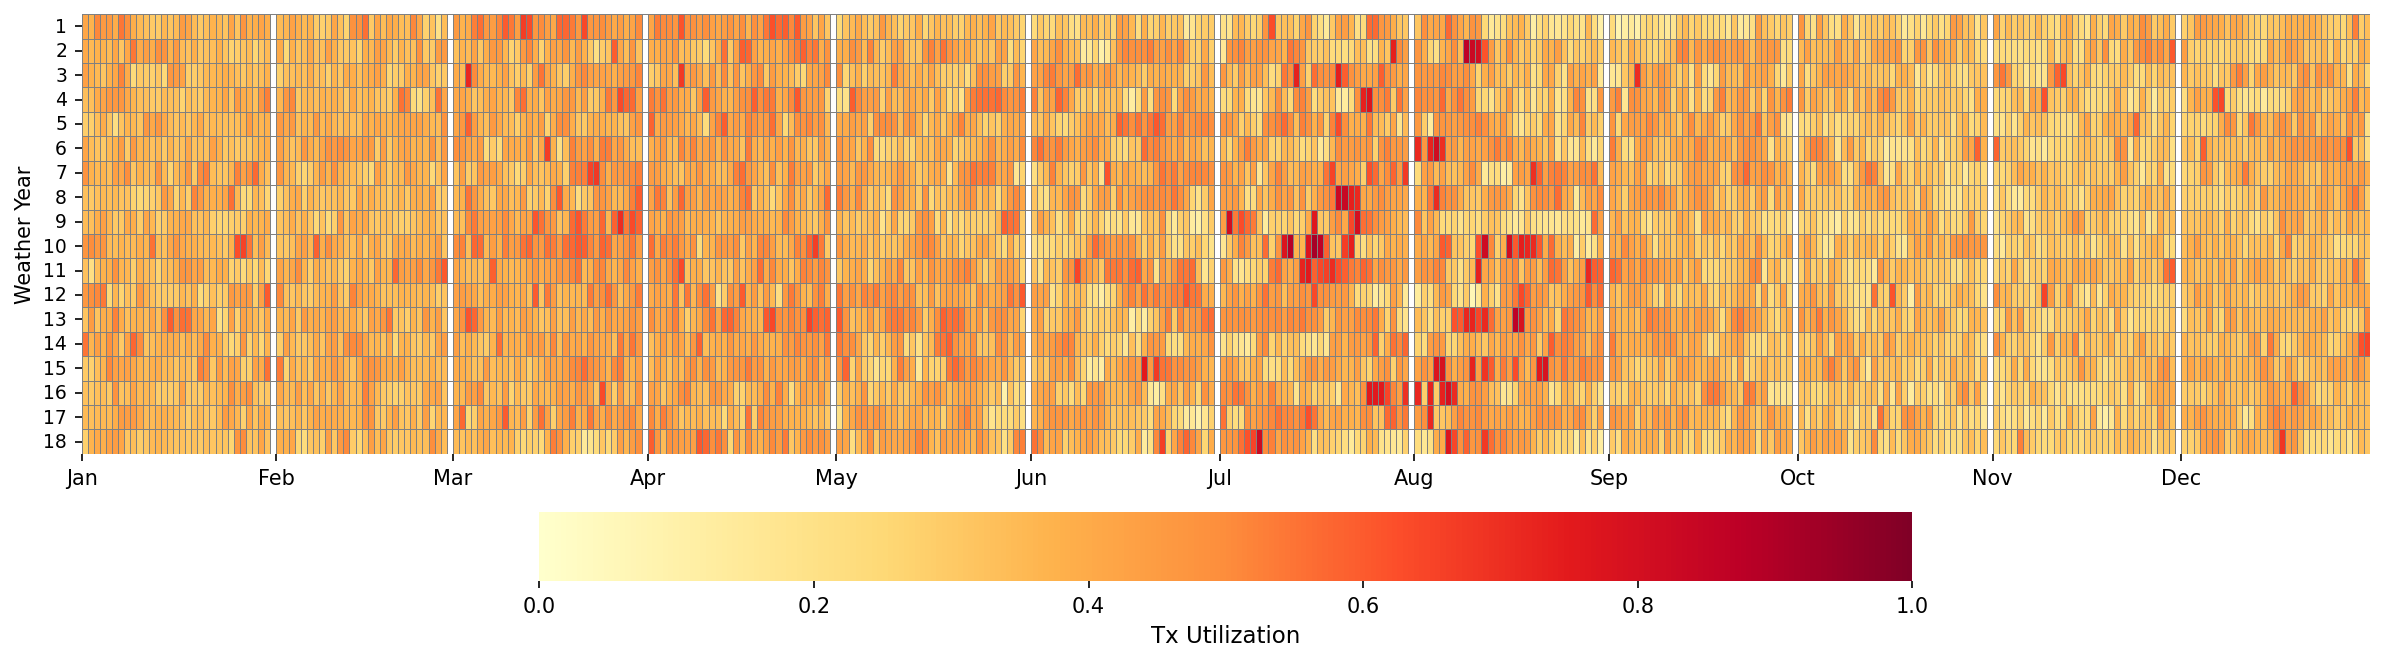

In [21]:

def _create_and_show_heatmap(data, title, cmap, month_starts, month_labels,
                             vmin=0, vmax=1, cbar_kws=None, cbar_label=None):
    """Helper function to create and display a single heatmap with blank gaps between months (no outlines)."""

    # --- Insert NaN gap columns between months (width = 1 col) ---
    def _insert_month_gaps(arr, starts, gap_width=1):
        parts = []
        nrows, ncols = arr.shape
        for i, s in enumerate(starts):
            e = starts[i+1] if i+1 < len(starts) else ncols
            parts.append(arr[:, s:e])
            if i < len(starts) - 1:
                parts.append(np.full((nrows, gap_width), np.nan))
        arr_gapped = np.concatenate(parts, axis=1)
        tick_pos = [s + i*gap_width for i, s in enumerate(starts)]
        return arr_gapped, tick_pos

    # Figure size logic unchanged
    figsize = (16, 4.5) if cbar_kws else (16, 3.5)
    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Ensure numpy array, then add gaps
    arr = np.asarray(data)
    arr_gapped, tick_positions = _insert_month_gaps(arr, month_starts, gap_width=1)

    hm = sns.heatmap(
        arr_gapped, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
        linewidths=0.4, linecolor="grey",
        cbar=bool(cbar_kws), cbar_kws=cbar_kws
    )
    ax.set_title(title, loc="left", fontsize=14)
    ax.set_ylabel("Weather Year")

    if cbar_label:
        hm.figure.axes[-1].set_xlabel(cbar_label, fontsize=11)

    # X-axis ticks/labels (aligned to month starts after gaps)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_labels, rotation=0, fontsize=10)

    # Y-axis ticks: all iteration numbers, horizontal, left only
    ax.set_yticks(np.arange(arr_gapped.shape[0]) + 0.5)
    ax.set_yticklabels(np.arange(1, arr_gapped.shape[0] + 1), fontsize=9, rotation=0)

    plt.tight_layout()
    plt.show()


def plot_zone_dashboard_refactored(selected_zone,
                                   plf_df,
                                   df_transmission_timepoints_zone,
                                   df_dispatch_,
                                   freq="D"):
    """
    Generates and displays six individual heatmap plots using a helper function.
    """
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}
    no_cbar_cmap = ListedColormap(['white', 'red'])

    vmax_plf = float(np.nanmax(heat.values)) if np.isfinite(np.nanmax(heat.values)) else 1.0
    _create_and_show_heatmap(heat, f"{selected_zone}", "YlGnBu", **common_args,
                             vmax=vmax_plf, cbar_kws=cbar_settings, cbar_label="VRE CF")

    _create_and_show_heatmap(flag, "RE Drought", no_cbar_cmap, **common_args)

    _create_and_show_heatmap(net, "Top Net-Load Days", no_cbar_cmap, **common_args)

    _create_and_show_heatmap(shed, "Load Shedding", no_cbar_cmap, **common_args)

    _create_and_show_heatmap(caf_mat, "", "PuBu",
                             **common_args, cbar_kws=cbar_settings, cbar_label="Thermal Availability")

    _create_and_show_heatmap(tx_mat, "", "YlOrRd", **common_args,
                             cbar_kws=cbar_settings, cbar_label="Tx Utilization")

# Example usage:
plot_zone_dashboard_refactored(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

#heatmap of the loss of load

In [22]:
def plot_national_dashboard(plf_df,
                            df_load_,
                            df_dispatch_,
                            df_transmission_timepoints_zone,
                            freq="D"):
    """Generate 6 separate heatmaps for National level."""

    # --- Build national-level aggregates ---
    df_nat_load, df_nat_dispatch, df_nat_tx = build_national_df(
        df_load_, df_dispatch_, df_transmission_timepoints_zone
    )

    # --- Ensure plf_df has National rows ---
    plf_df_nat = build_national_plf(plf_df)

    # --- Build matrices (reuse existing functions) ---
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats("National", plf_df_nat, df_nat_tx, df_nat_dispatch, freq=freq)

    iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats("National", plf_df_nat, df_nat_load, df_nat_dispatch, df_nat_tx, fy=None)

    # --- Shared plotting settings ---
    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}
    no_cbar_cmap = ListedColormap(['white', 'red'])

    # --- Plots ---
    vmax_plf = float(np.nanmax(heat.values)) if np.isfinite(np.nanmax(heat.values)) else 1.0
    _create_and_show_heatmap(heat, "PLF — National", "YlGnBu", **common_args,
                             vmax=vmax_plf, cbar_kws=cbar_settings, cbar_label="PLF")

    _create_and_show_heatmap(flag, "RE Drought — National", no_cbar_cmap, **common_args)
    _create_and_show_heatmap(net, "Top Net-Load Days — National", no_cbar_cmap, **common_args)
    _create_and_show_heatmap(shed, "Load Shedding — National", no_cbar_cmap, **common_args)

    _create_and_show_heatmap(caf_mat, "Combined Availability Factor — National", "PuBu",
                             **common_args, cbar_kws=cbar_settings, cbar_label="Combined AF")

    _create_and_show_heatmap(tx_mat, "Transmission Capacity Factor — National", "YlOrRd",
                             **common_args, cbar_kws=cbar_settings, cbar_label="Tx Cap Factor")

In [23]:
def plot_zone_hydro_storage_cf_heatmap(selected_zone,
                                       plf_df,
                                       df_dispatch_,
                                       df_transmission_timepoints_zone,
                                       freq="D"):
    """Generate a Hydro_Storage daily capacity factor heatmap for a state or National, same style as dashboard."""

    # --- Ensure National rows exist if needed ---
    if selected_zone == "National":
        plf_df = build_national_plf(plf_df)

    # --- Build matrices (to get iteration axis + month labels) ---
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats(selected_zone, plf_df,
                        df_transmission_timepoints_zone, df_dispatch_, freq=freq)

    # --- Filter Hydro_Storage dispatch ---
    df_zone_dispatch = df_dispatch_[df_dispatch_['load_zone'] == selected_zone].copy()
    df_zone_dispatch = _ensure_timestamp(df_zone_dispatch, 'timepoint')
    df_zone_dispatch = _norm(df_zone_dispatch)

    hydro = df_zone_dispatch[df_zone_dispatch['technology'].str.contains("Hydro_Storage", case=False, na=False)].copy()
    if hydro.empty:
        print(f"No Hydro_Storage data found for {selected_zone}")
        return

    # --- Compute daily energy and daily capacity-hours ---
    daily_cf = (hydro.groupby(['W','H','A','date'], as_index=False)
                      .agg(energy_mwh_day=('power_mw','sum'),
                           cap_hour_sum_day=('capacity_mw','sum')))

    # --- Capacity factor = energy ÷ capacity-hours ---
    daily_cf['hydro_storage_cf'] = np.where(
        daily_cf['cap_hour_sum_day'] > 0,
        daily_cf['energy_mwh_day'] / daily_cf['cap_hour_sum_day'],
        np.nan
    )

    # --- Pivot Iteration × Date ---
    HYDRO_CF = (it_master.merge(daily_cf, on=['W','H','A'], how='left')
                          .pivot_table(index='iteration',
                                       columns='date',
                                       values='hydro_storage_cf',
                                       aggfunc='mean')
                          .reindex(index=it_master['iteration']))

    # --- Plot ---
    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}

    _create_and_show_heatmap(HYDRO_CF,
                             f"Hydro_Storage Daily Capacity Factor — {selected_zone}",
                             "PuBu",
                             vmin=0, vmax=1.0,
                             **common_args,
                             cbar_kws=cbar_settings,
                             cbar_label="Hydro_Storage CF")

In [24]:
# For a state
plot_zone_hydro_storage_cf_heatmap("Kerala", plf_df, df_dispatch_, df_transmission_timepoints_zone, freq="D")

# For National (auto-handles National PLF inside)
plot_zone_hydro_storage_cf_heatmap("National", plf_df, df_dispatch_, df_transmission_timepoints_zone, freq="D")

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),


NameError: name '_ensure_timestamp' is not defined

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
/tmp/ipykernel_721687/757495019.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font

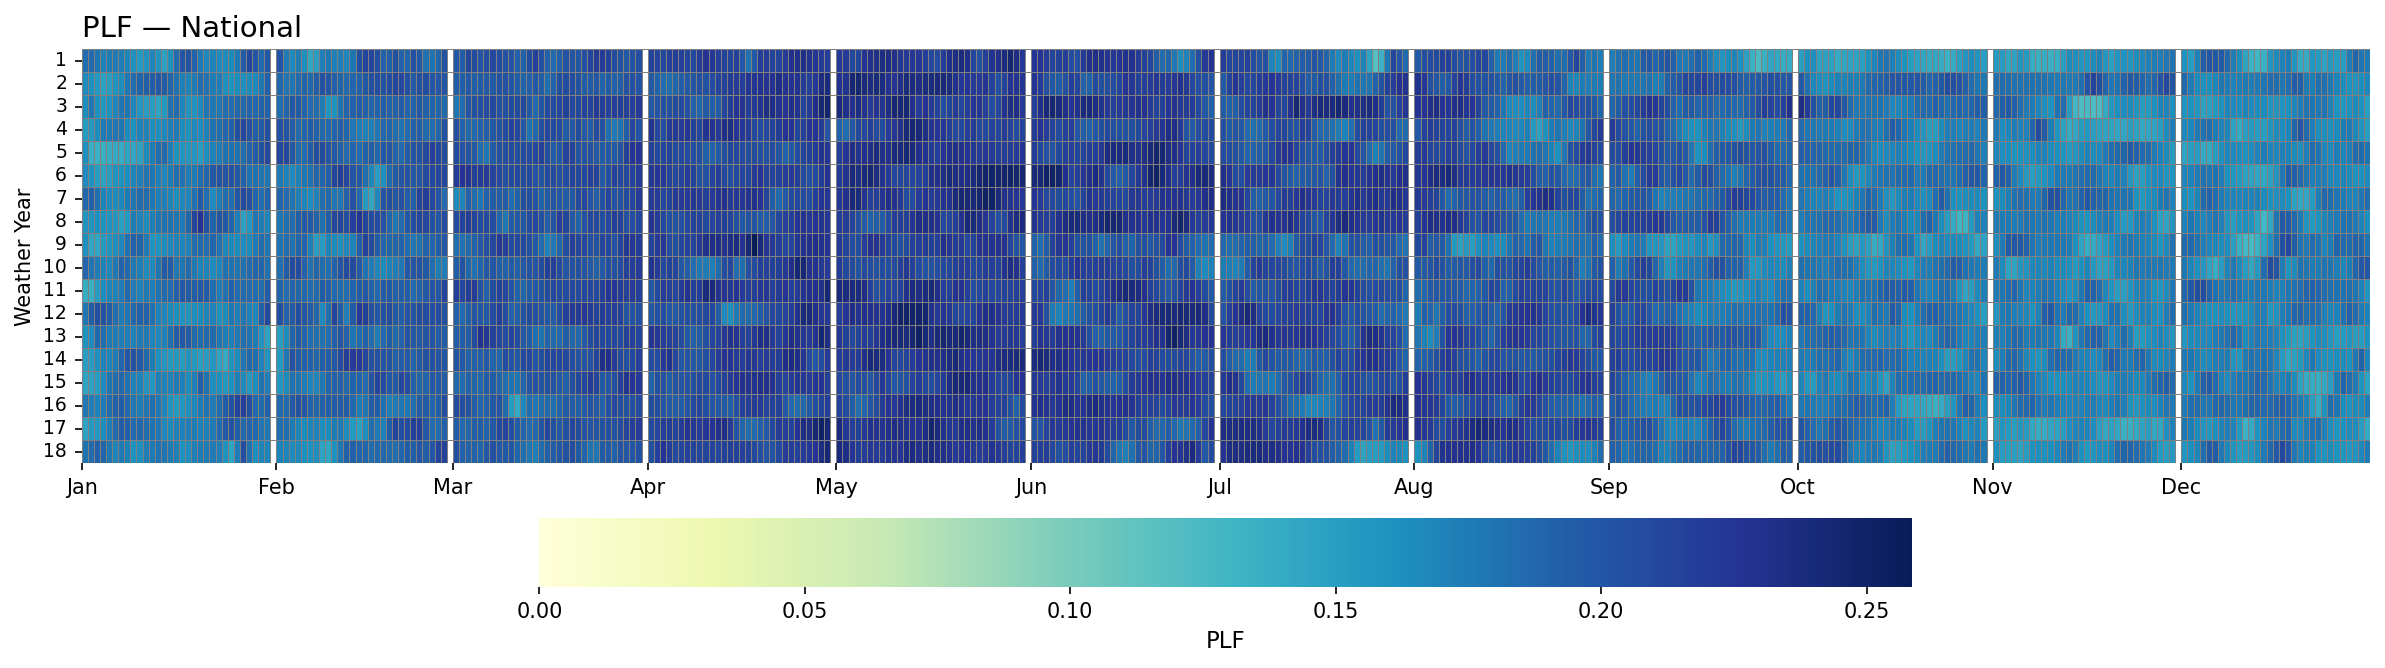

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

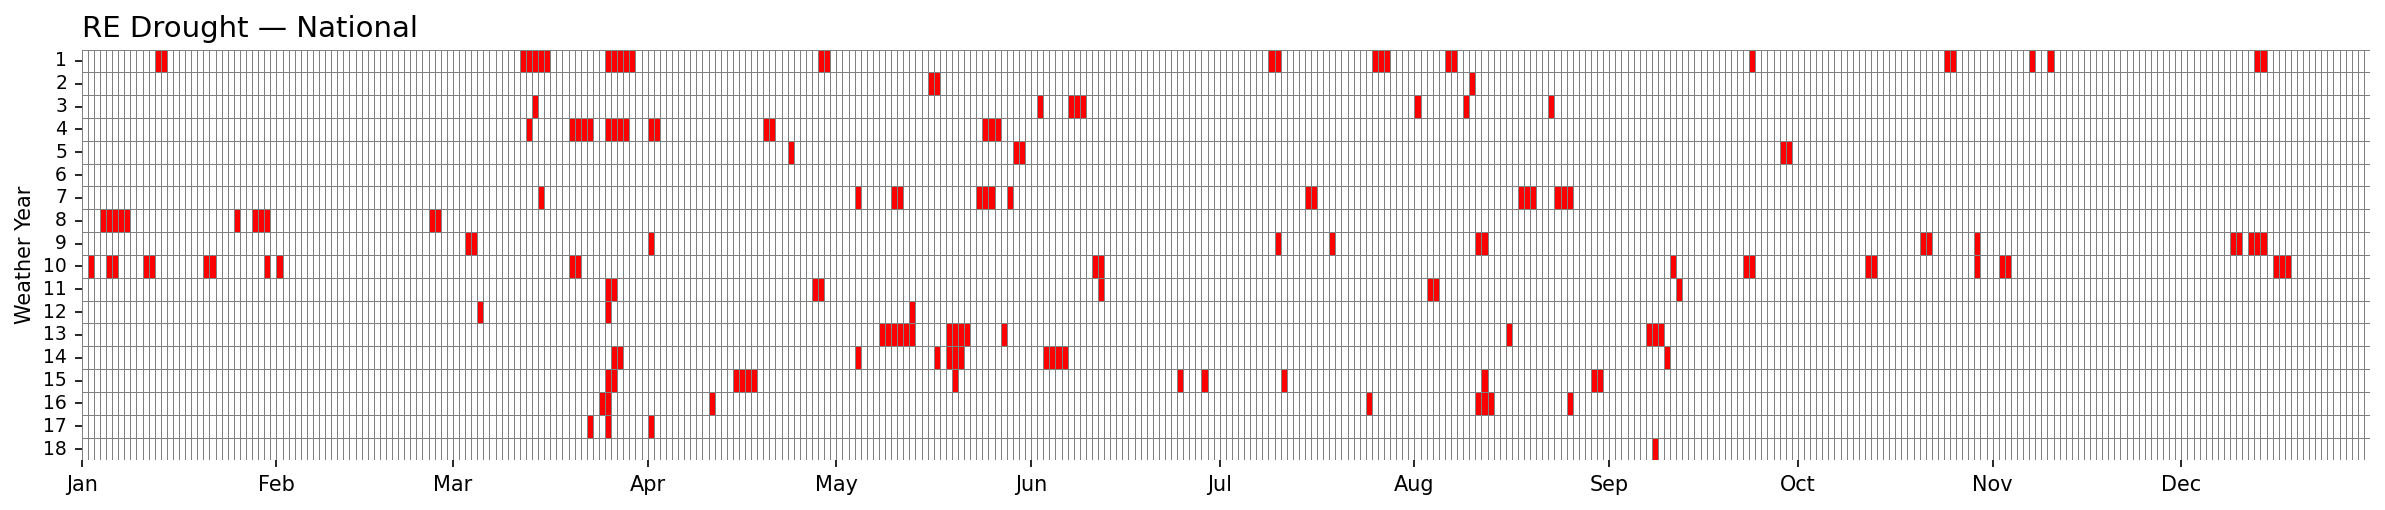

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

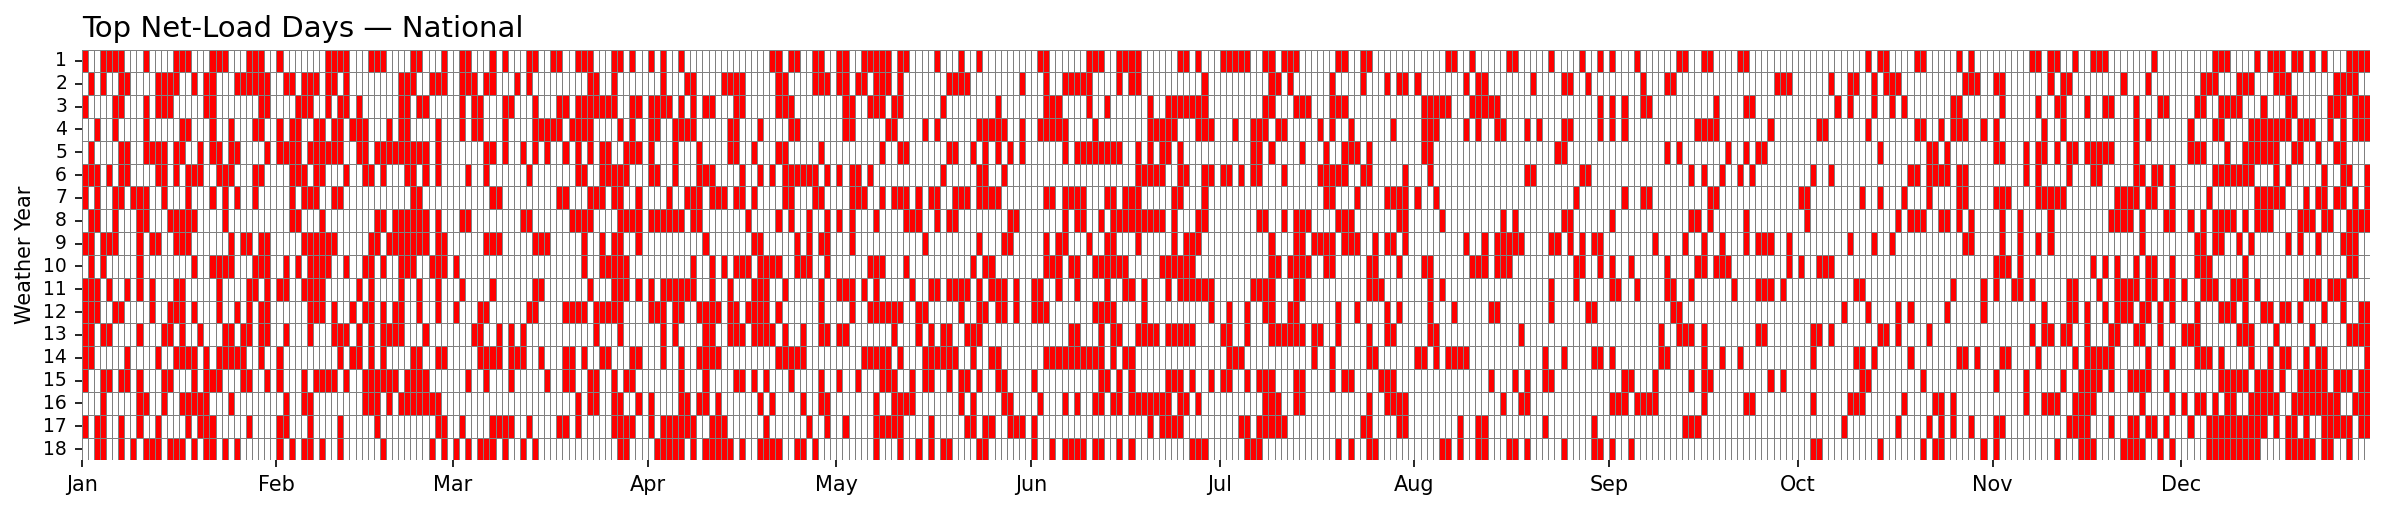

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

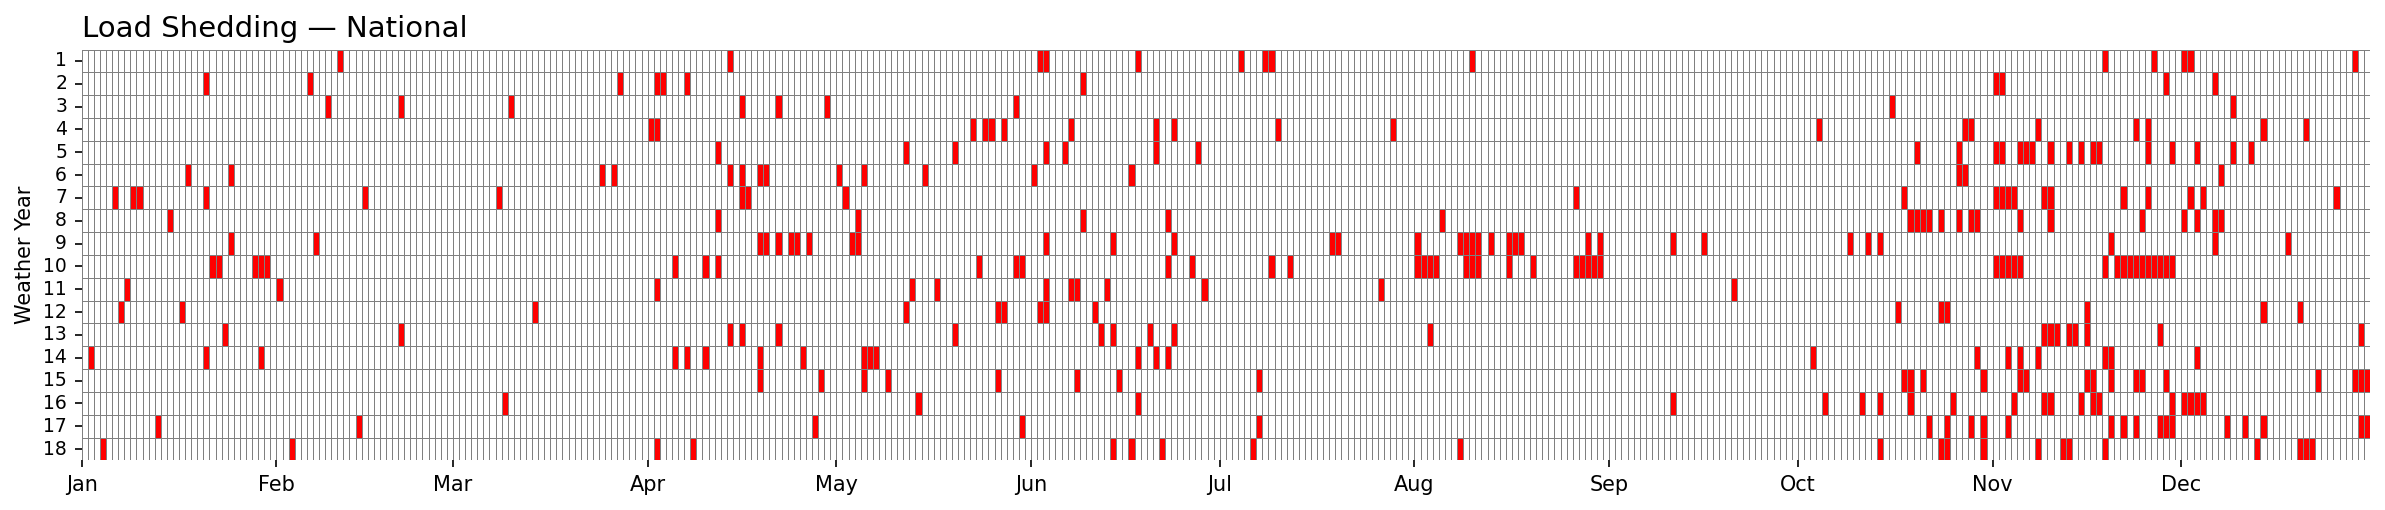

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

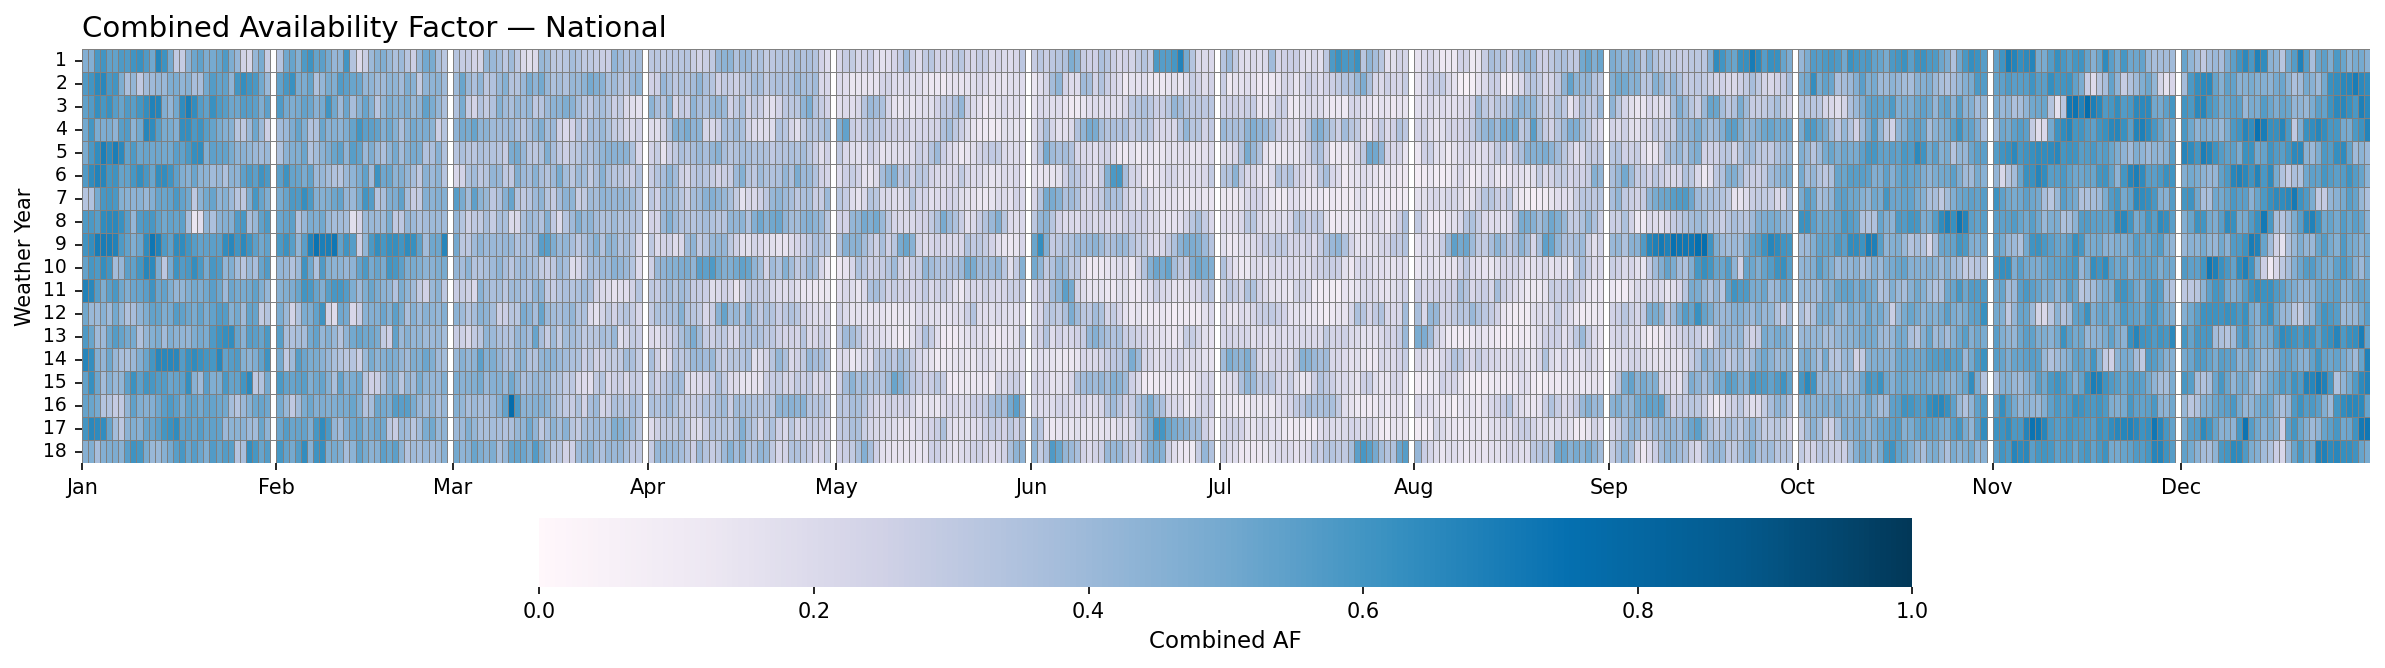

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

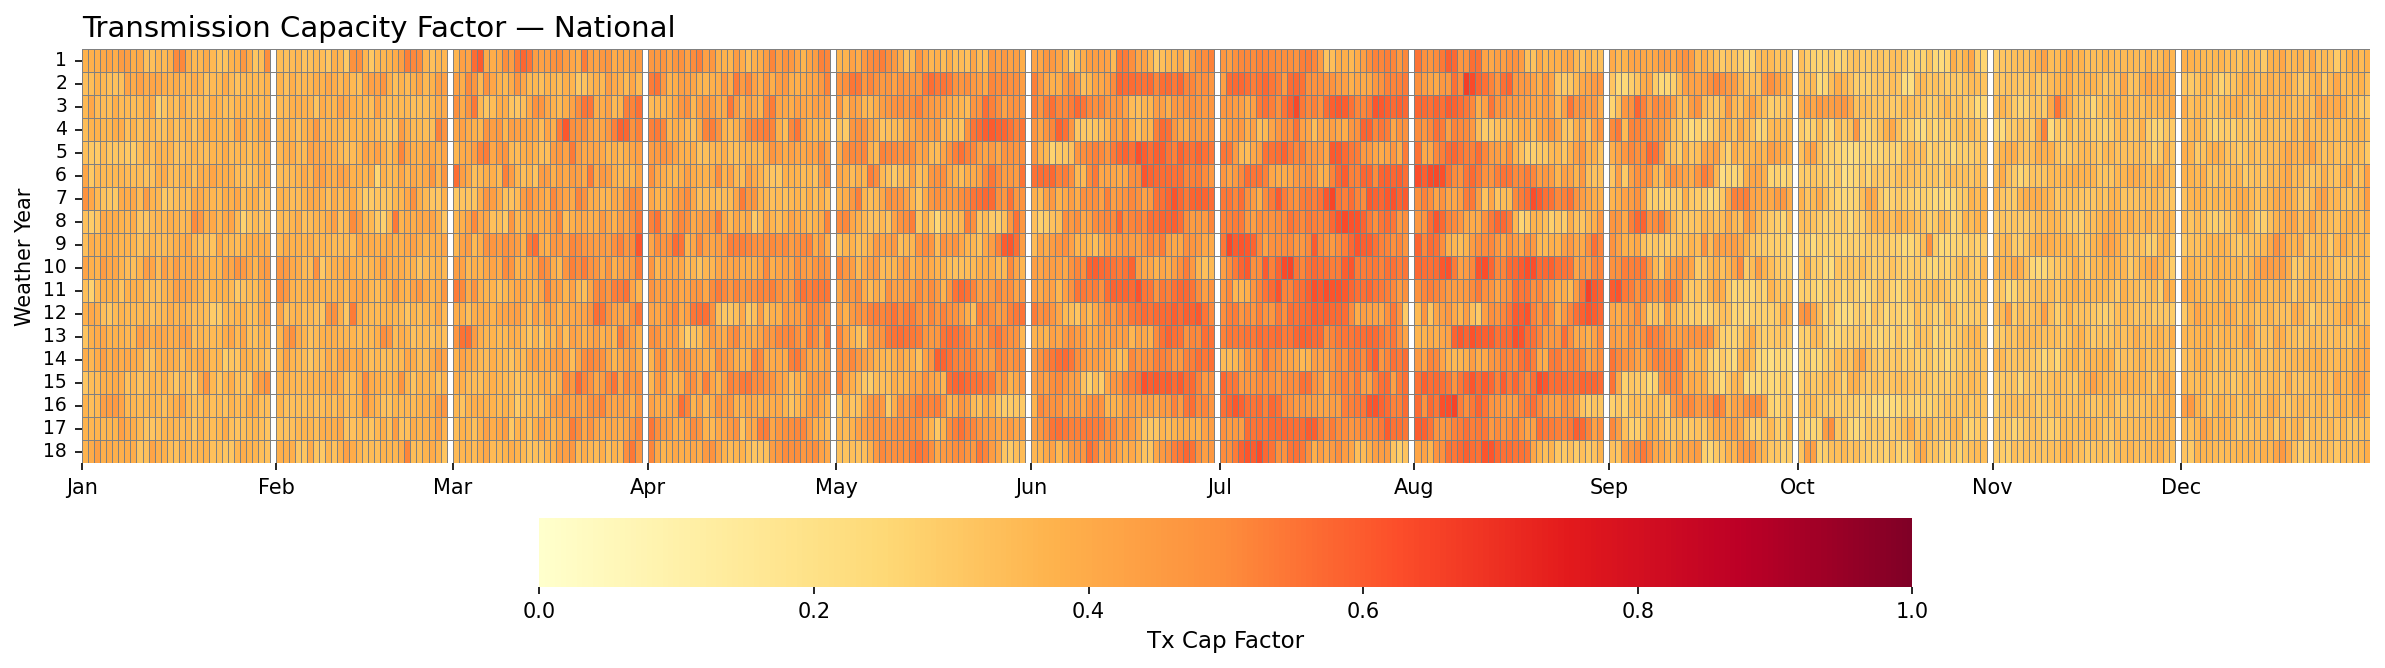

In [42]:
plot_national_dashboard(plf_df,
                        df_load_,
                        df_dispatch_,
                        df_transmission_timepoints_zone,
                        freq="D")

# National level dataframe

# Incident

/tmp/ipykernel_721687/757495019.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fami

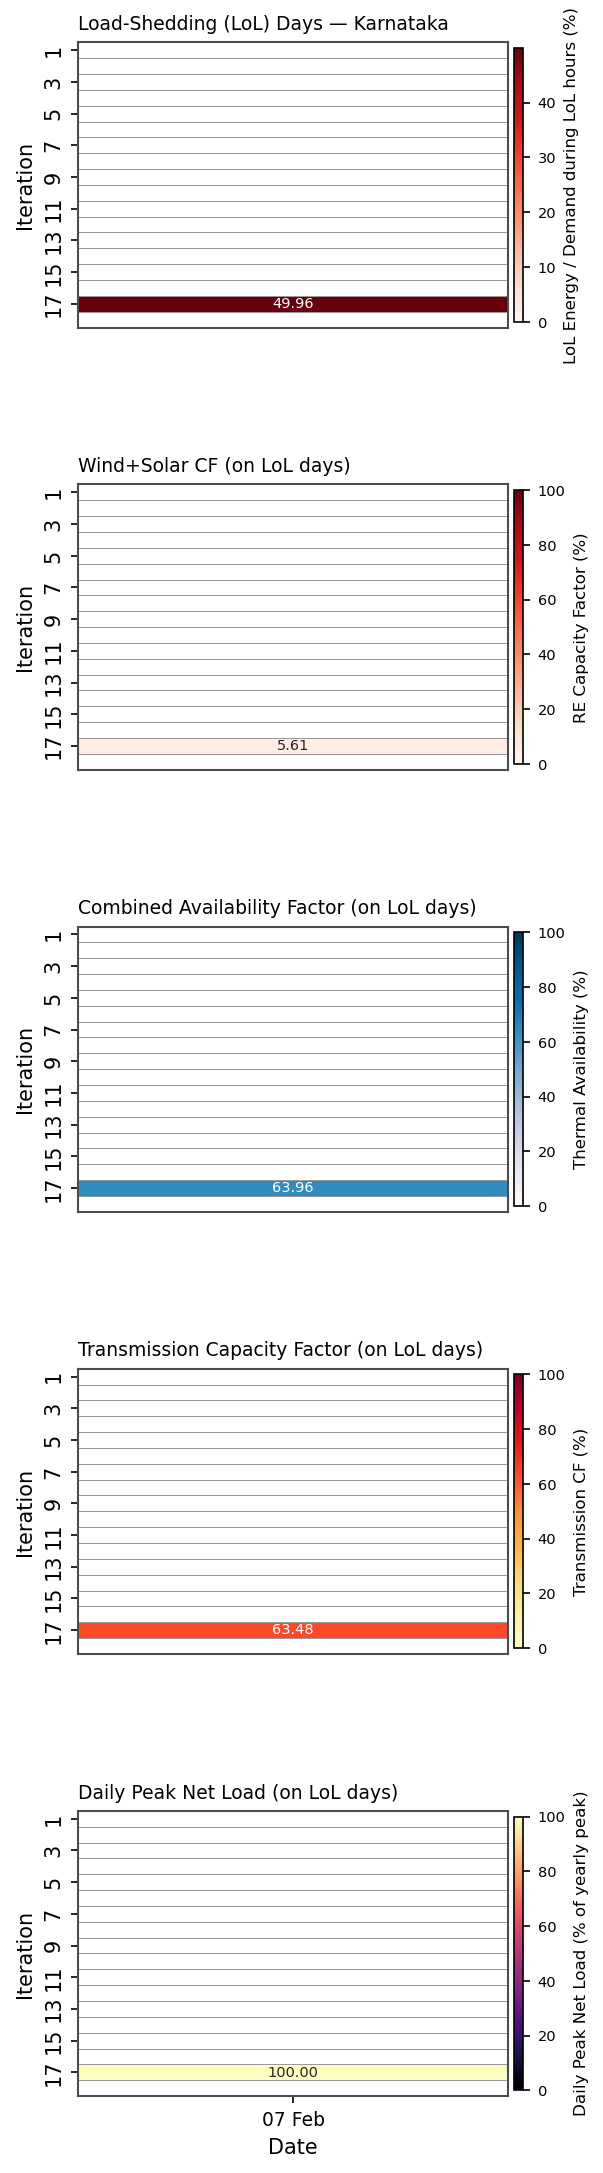

In [26]:

selected_zone = "Kerala"  
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip

plt.rcParams.update({"font.family": "Arial", "font.size": 10})

def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

# i == W==H==A
def _iter_table(zone_df):
    """
    Keep only diagonal runs (W==H==A) and set iteration = int(W).
    Return W/H/A as strings so merges keep working exactly as before.
    """
    it = zone_df[['W','H','A']].drop_duplicates().copy()

    # coerce to numeric to test equality safely
    w = pd.to_numeric(it['W'], errors='coerce')
    h = pd.to_numeric(it['H'], errors='coerce')
    a = pd.to_numeric(it['A'], errors='coerce')

    it = it[(w.notna()) & (w == h) & (h == a)].copy()
    it['iteration'] = w.loc[it.index].astype(int)

    # re-write W/H/A as the iteration number (string form) to avoid any drift
    it['W'] = it['iteration'].astype(str)
    it['H'] = it['iteration'].astype(str)
    it['A'] = it['iteration'].astype(str)

    it = it[['W','H','A','iteration']].drop_duplicates().sort_values('iteration').reset_index(drop=True)
    return it
# ===========================================================================

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1):
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')


def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No diagonal (W==H==A) iterations found in plf_df for '{selected_zone}'.")

    # --- Daily LoL (zone) ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary 0/1)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates)
                 .fillna(0).astype('int8'))

    # === LoL % = (sum UE on LoL hours) / (sum static load on SAME hours) × 100 ===
    load_zone = load[load['load_zone'] == selected_zone].copy()
    lol_hours = load_zone[load_zone['unserved_energy'] > 0].copy()  # only hours with LoL
    lol_ratio_day = (lol_hours.groupby(['W','H','A','date'], as_index=False)
                               .agg(ue=('unserved_energy','sum'),
                                    demand=('static_load','sum')))
    lol_ratio_day['lol_ratio_pct'] = np.where(
        lol_ratio_day['demand'] > 0, 100.0 * lol_ratio_day['ue'] / lol_ratio_day['demand'], np.nan
    )
    LoL_ratio_pct = (iters.merge(lol_ratio_day[['W','H','A','date','lol_ratio_pct']], on=['W','H','A'], how='left')
                          .pivot_table(index='iteration', columns='date', values='lol_ratio_pct', aggfunc='sum')
                          .reindex(index=iters['iteration'], columns=lol_dates))
    LoL_ratio_pct = LoL_ratio_pct.where(LoL==1)

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]
    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt


def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    # Unpack with LoL_ratio_pct as second output
    iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space
    n_iters = LoL_ratio_pct.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # (1) LoL % panel
    annot_lol = _should_annot(LoL_ratio_pct)
    vmax_lol  = float(np.nanmax(LoL_ratio_pct.values)) if np.isfinite(np.nanmax(LoL_ratio_pct.values)) else 0.0
    hm_lol = sns.heatmap(
        LoL_ratio_pct, ax=ax_lol, cmap="Reds", vmin=0, vmax=vmax_lol if vmax_lol>0 else 1,
        mask=LoL_ratio_pct.isna(), annot=annot_lol, fmt=".2f",
        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs
    )
    _right_cbar(ax_lol, hm_lol.collections[0], "LoL Energy / Demand during LoL hours (%)")
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}", loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # (2) RE CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # (3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # (4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%)")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # (5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # X‑ticks only on bottom
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

# run
plot_lol_story_sidebars(
    # selected_zone=selected_zone,
    selected_zone="Karnataka",
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # set True to force numbers in every cell (can crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams.update({"font.family": "Arial", "font.size": 10})

# ===========================================
# Timestamp + helpers
# ===========================================
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

def _iter_table(zone_df):
    """Keep only diagonal runs (W==H==A) and set iteration = int(W)."""
    it = zone_df[['W','H','A']].drop_duplicates().copy()
    w = pd.to_numeric(it['W'], errors='coerce')
    h = pd.to_numeric(it['H'], errors='coerce')
    a = pd.to_numeric(it['A'], errors='coerce')
    it = it[(w.notna()) & (w == h) & (h == a)].copy()
    it['iteration'] = w.loc[it.index].astype(int)
    it['W'] = it['iteration'].astype(str)
    it['H'] = it['iteration'].astype(str)
    it['A'] = it['iteration'].astype(str)
    it = it[['W','H','A','iteration']].drop_duplicates().sort_values('iteration').reset_index(drop=True)
    return it

def _infer_availability_series(df):
    """Capacity-weighted availability (0..1)."""
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')


# ===========================================
# National aggregators
# ===========================================
def build_national_df(df_load_, df_dispatch_, df_transmission_timepoints_zone):
    """Aggregate load, dispatch, and transmission to create 'National' zone."""

    # --- Load side ---
    df_nat_load = (df_load_.copy()
                   .groupby(['timepoint','W','H','A'], as_index=False)
                   [['static_load','unserved_energy']]
                   .sum())
    df_nat_load['load_zone'] = "National"

    # --- Dispatch side ---
    df_nat_dispatch = (df_dispatch_.copy()
                       .groupby(['timepoint','technology','W','H','A'], as_index=False)
                       [['power_mw','capacity_mw']]
                       .sum())
    df_nat_dispatch['load_zone'] = "National"

    # --- Transmission side ---
    df_nat_tx = (df_transmission_timepoints_zone.copy()
                 .groupby(['timepoint','W','H','A'], as_index=False)
                 [['zone_transmission_flow_mw','zone_max_mw']]
                 .sum())
    df_nat_tx['load_zone'] = "National"
    df_nat_tx['tx_cap_factor'] = df_nat_tx['zone_transmission_flow_mw'] / \
                                 df_nat_tx['zone_max_mw'].replace({0: np.nan})

    return df_nat_load, df_nat_dispatch, df_nat_tx


def build_national_plf(plf_df):
    """Aggregate PLF-related metrics to create a National row in plf_df."""
    nat = (plf_df.groupby(['W','H','A','date'], as_index=False)
                  .agg({
                      'plf':'mean',
                      'low_plf_flag':'max',
                      'net_load':'max',
                      'load_shedding':'max'
                  }))
    nat['load_zone'] = "National"
    return pd.concat([plf_df, nat], ignore_index=True)


# ===========================================
# National wrapper for LoL story sidebars
# ===========================================
def plot_national_lol_sidebars(plf_df,
                               df_load_,
                               df_dispatch_,
                               df_transmission_timepoints_zone,
                               fy=None,
                               always_annot=False,
                               annot_threshold_cells=700):
    """Run LoL story sidebars for National level."""

    # Aggregate to National
    df_nat_load, df_nat_dispatch, df_nat_tx = build_national_df(
        df_load_, df_dispatch_, df_transmission_timepoints_zone
    )
    plf_df_nat = build_national_plf(plf_df)

    # Call your existing function (must already be defined)
    plot_lol_story_sidebars(
        selected_zone="National",
        plf_df=plf_df_nat,
        df_load_=df_nat_load,
        df_dispatch_=df_nat_dispatch,
        df_tx_zone=df_nat_tx,
        fy=fy,
        always_annot=always_annot,
        annot_threshold_cells=annot_threshold_cells
    )

/tmp/ipykernel_721687/757495019.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fami

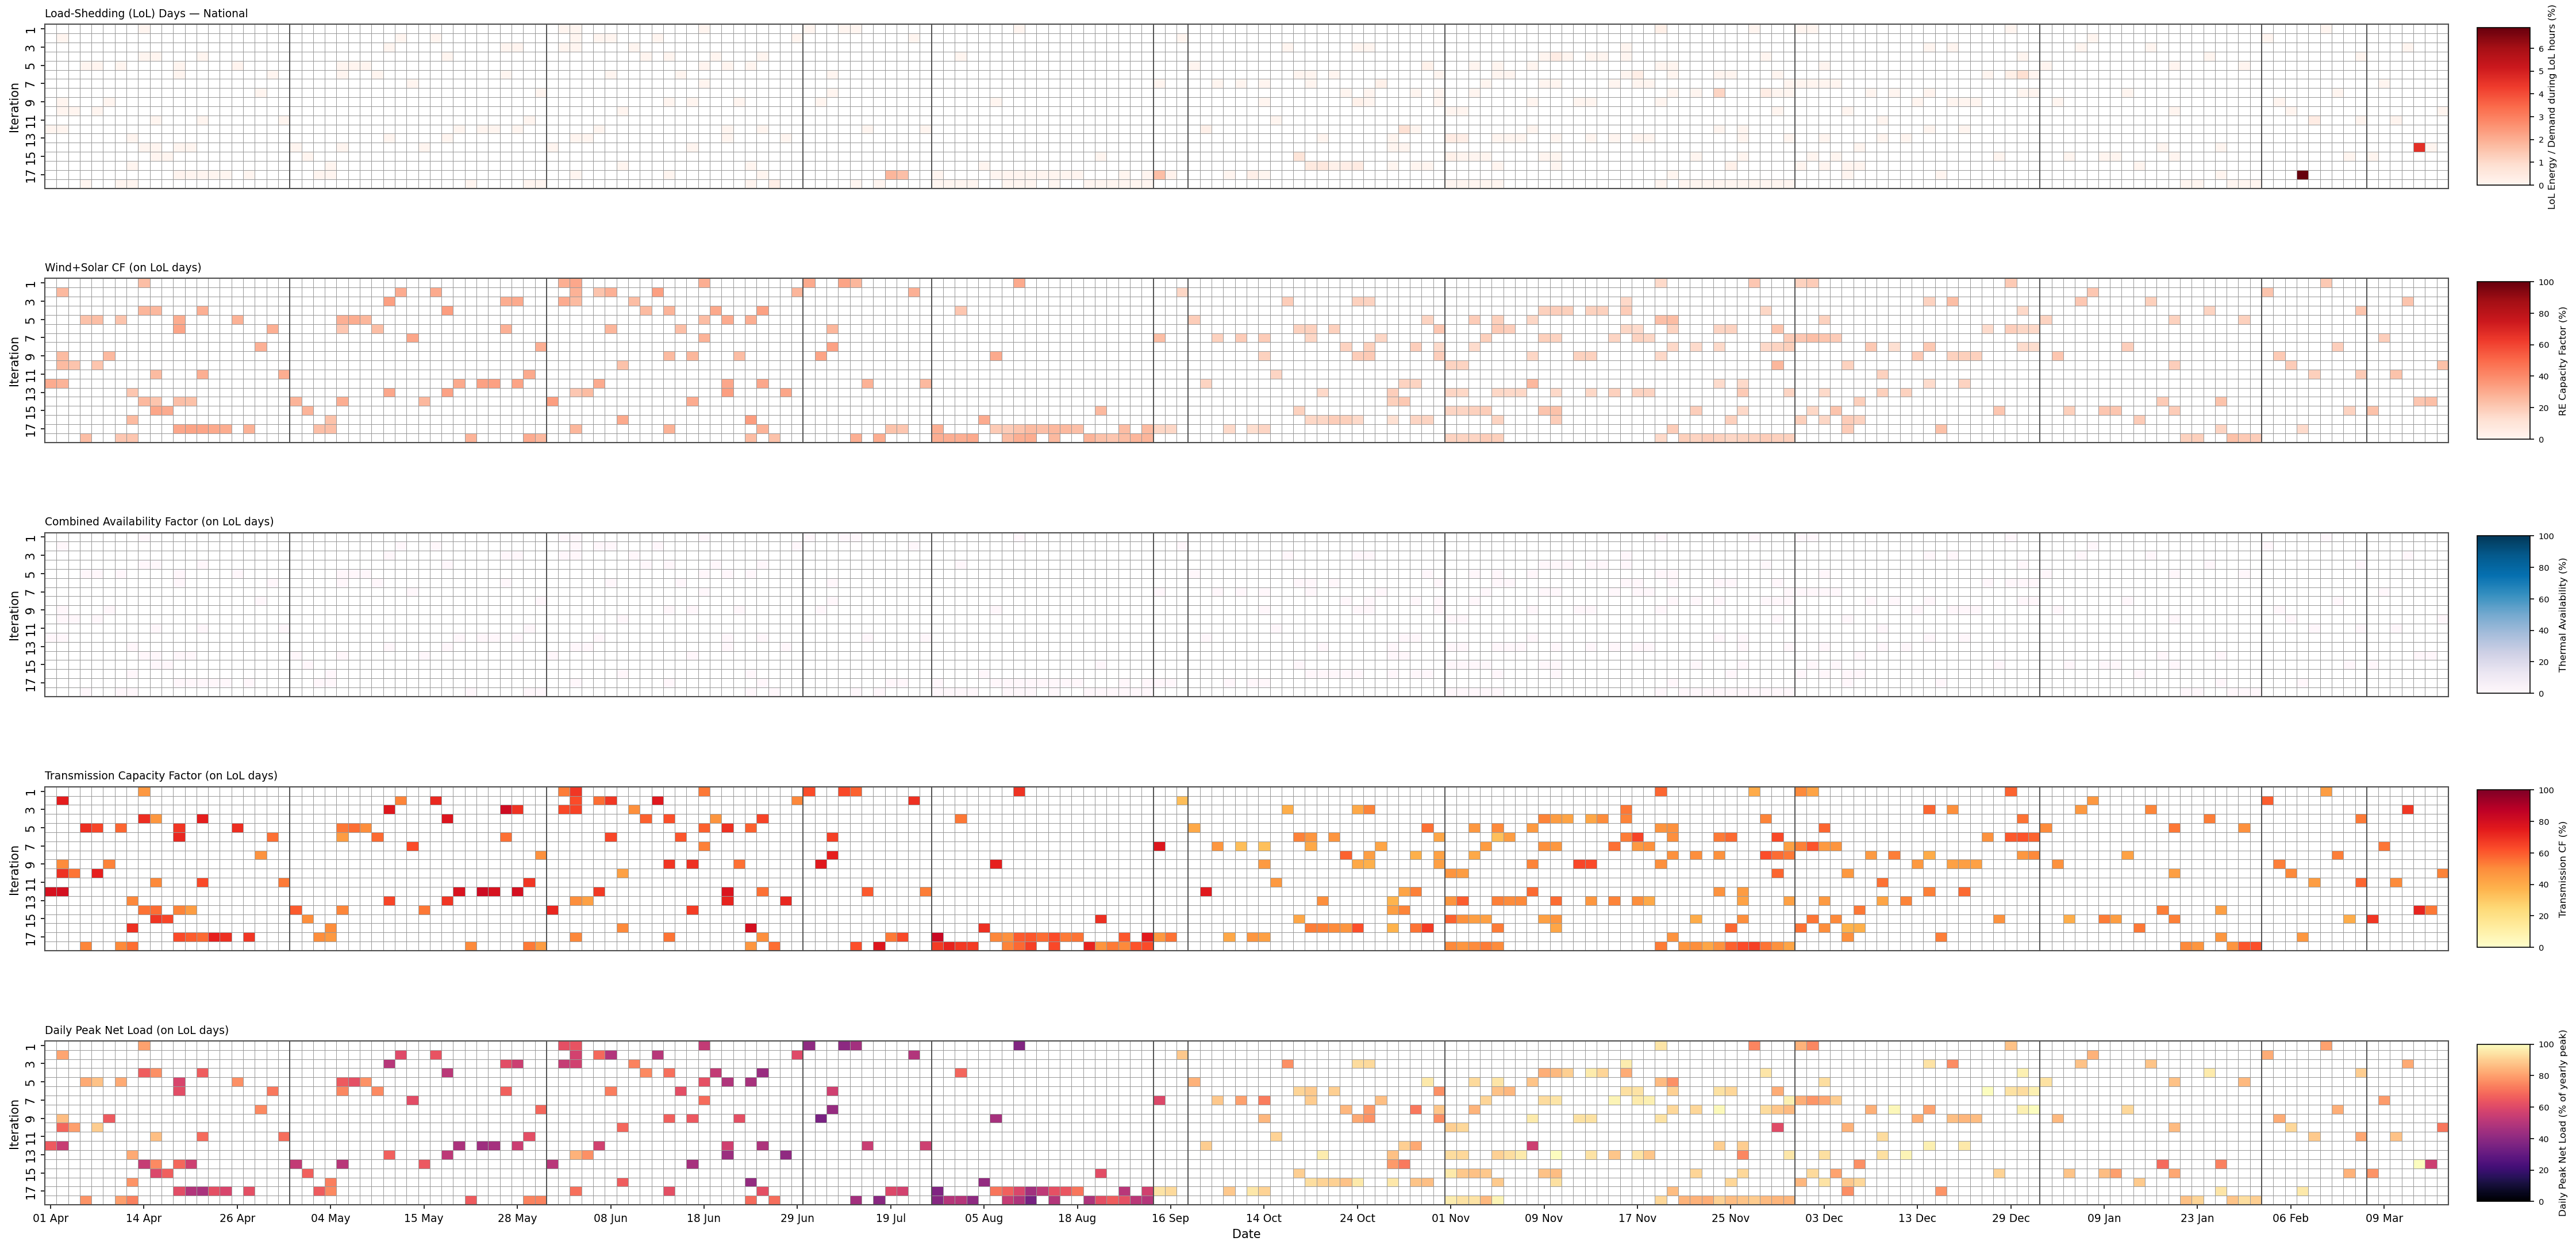

In [28]:
plot_national_lol_sidebars(plf_df,
                           df_load_,
                           df_dispatch_,
                           df_transmission_timepoints_zone,
                           fy=None)

In [29]:
def plot_national_load_heatmap(plf_df,
                               df_load_,
                               df_dispatch_,
                               df_transmission_timepoints_zone,
                               freq="D"):
    """Generate a Daily Load (MWh) heatmap for National level, same style as dashboard."""

    # --- Build national-level aggregates ---
    df_nat_load, df_nat_dispatch, df_nat_tx = build_national_df(
        df_load_, df_dispatch_, df_transmission_timepoints_zone
    )

    # --- Ensure plf_df has National rows ---
    plf_df_nat = build_national_plf(plf_df)

    # --- Build matrices (reuse existing functions) ---
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats("National", plf_df_nat, df_nat_tx, df_nat_dispatch, freq=freq)

    # --- Build daily load matrix ---
    df_nat_load = _ensure_timestamp(df_nat_load, 'timepoint')
    df_nat_load = _norm(df_nat_load)

    daily_load = (df_nat_load.groupby(['W','H','A','date'], as_index=False)
                               ['static_load'].sum()
                               .rename(columns={'static_load':'daily_load_mwh'}))

    LOAD_MWh = (it_master.merge(daily_load, on=['W','H','A'], how='left')
                          .pivot_table(index='iteration',
                                       columns='date',
                                       values='daily_load_mwh',
                                       aggfunc='sum')
                          .reindex(index=it_master['iteration']))

    # --- Shared plotting settings ---
    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}

    vmax_load = float(np.nanmax(LOAD_MWh.values)) if np.isfinite(np.nanmax(LOAD_MWh.values)) else 1.0
    _create_and_show_heatmap(LOAD_MWh, "Daily Load (MWh) — National", "Greens", **common_args,
                             vmax=vmax_load, cbar_kws=cbar_settings, cbar_label="Load (MWh)")

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

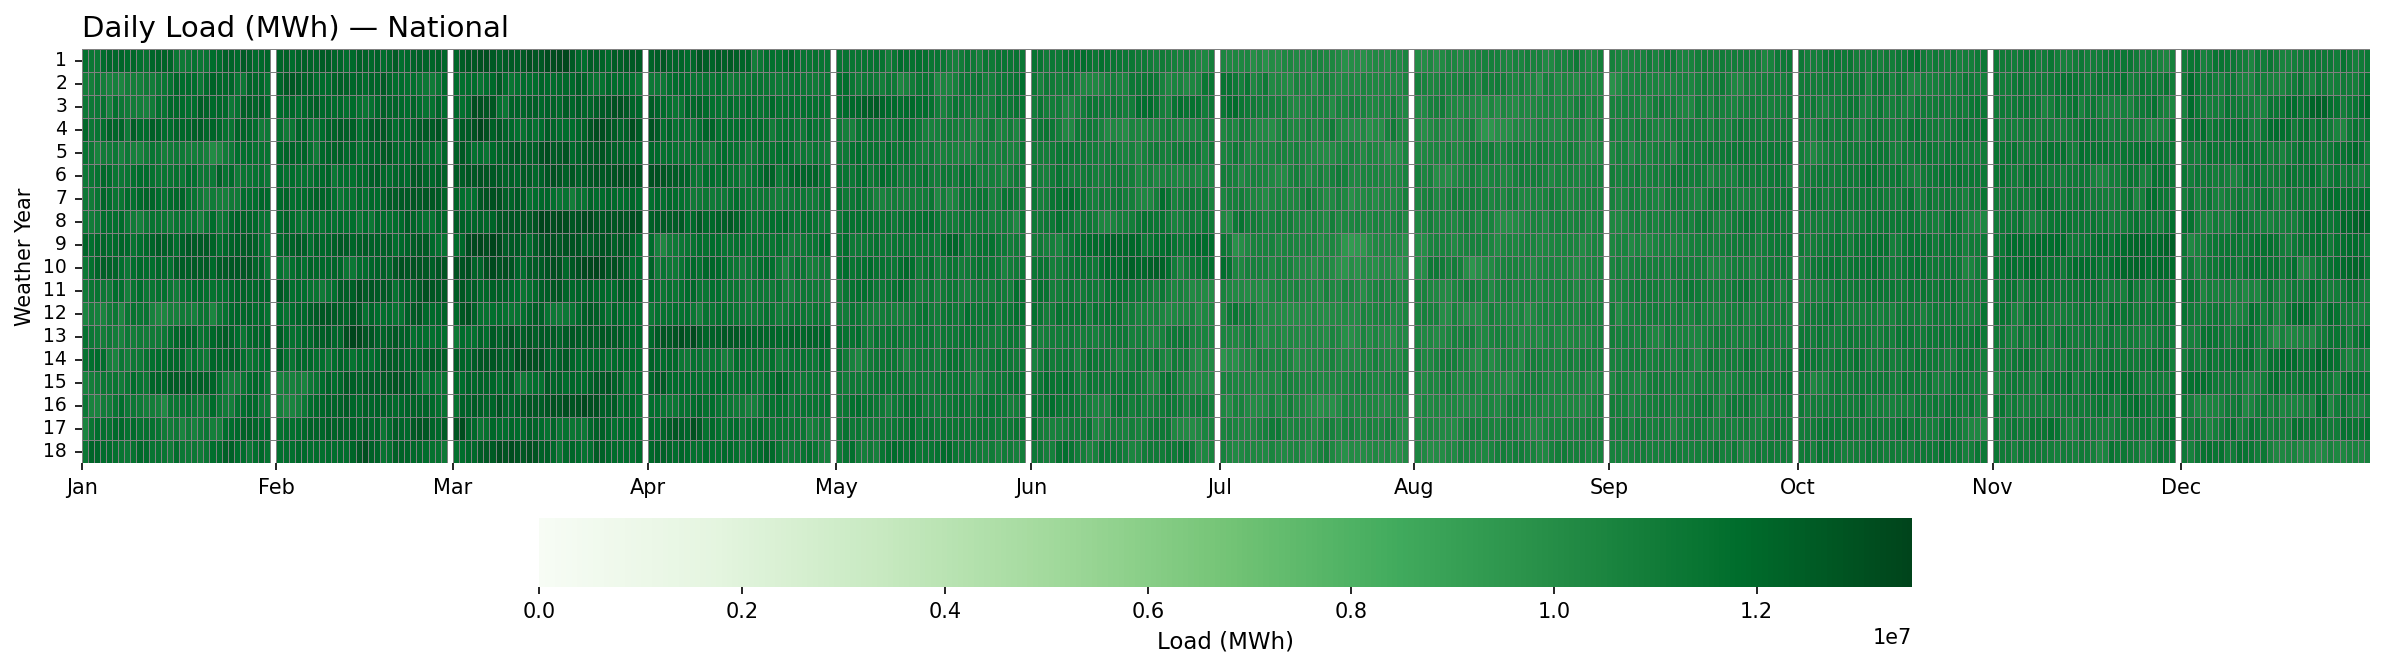

In [30]:
plot_national_load_heatmap(plf_df,
                           df_load_,
                           df_dispatch_,
                           df_transmission_timepoints_zone,
                           freq="D")

In [31]:
def plot_national_netload_heatmap(plf_df,
                                  df_load_,
                                  df_dispatch_,
                                  df_transmission_timepoints_zone,
                                  freq="D"):
    """Generate a Daily Net Load (MWh) heatmap for National level, same style as dashboard."""

    # --- Build national-level aggregates ---
    df_nat_load, df_nat_dispatch, df_nat_tx = build_national_df(
        df_load_, df_dispatch_, df_transmission_timepoints_zone
    )

    # --- Ensure plf_df has National rows ---
    plf_df_nat = build_national_plf(plf_df)

    # --- Build matrices (reuse existing functions) ---
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats("National", plf_df_nat, df_nat_tx, df_nat_dispatch, freq=freq)

    # --- Ensure timestamps ---
    df_nat_load = _ensure_timestamp(df_nat_load, 'timepoint')
    df_nat_load = _norm(df_nat_load)
    df_nat_dispatch = _ensure_timestamp(df_nat_dispatch, 'timepoint')
    df_nat_dispatch = _norm(df_nat_dispatch)

    # --- Compute Wind + Solar hourly generation ---
    ws = df_nat_dispatch.loc[df_nat_dispatch['technology'].isin(['Wind','Solar']),
                             ['timestamp','date','W','H','A','power_mw']].copy()
    re_hourly = ws.groupby(['W','H','A','timestamp','date'], as_index=False)['power_mw'].sum()

    # --- Merge with load ---
    load_hr = df_nat_load[['W','H','A','timestamp','date','static_load']].copy()
    net_hr = pd.merge(load_hr, re_hourly, on=['W','H','A','timestamp','date'], how='left')
    net_hr['power_mw'] = net_hr['power_mw'].fillna(0.0)
    net_hr['net_load_mw'] = net_hr['static_load'] - net_hr['power_mw']

    # --- Daily totals ---
    daily_netload = (net_hr.groupby(['W','H','A','date'], as_index=False)
                            ['net_load_mw'].sum()
                            .rename(columns={'net_load_mw':'daily_netload_mwh'}))

    # --- Pivot to Iteration × Date matrix ---
    NETLOAD_MWh = (it_master.merge(daily_netload, on=['W','H','A'], how='left')
                             .pivot_table(index='iteration',
                                          columns='date',
                                          values='daily_netload_mwh',
                                          aggfunc='sum')
                             .reindex(index=it_master['iteration']))

    # --- Shared plotting settings ---
    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}

    vmax_netload = float(np.nanmax(NETLOAD_MWh.values)) if np.isfinite(np.nanmax(NETLOAD_MWh.values)) else 1.0
    _create_and_show_heatmap(NETLOAD_MWh, "Daily Net Load (MWh) — National", "Blues", **common_args,
                             vmax=vmax_netload, cbar_kws=cbar_settings, cbar_label="Net Load (MWh)")

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

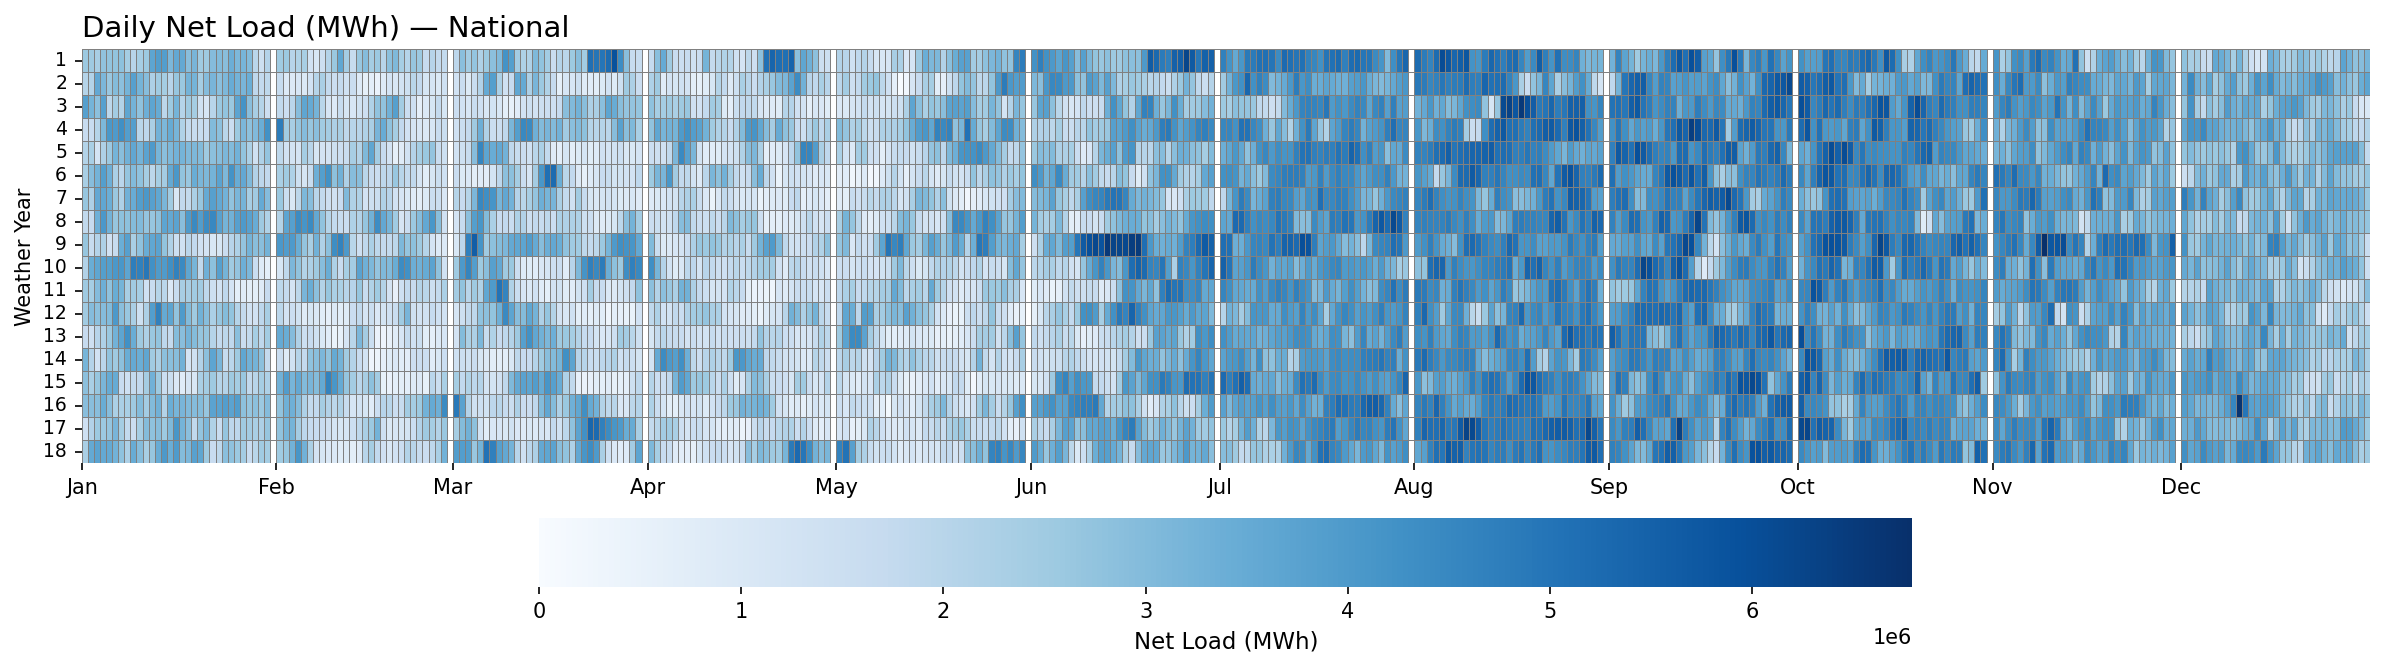

In [32]:
plot_national_netload_heatmap(plf_df,
                              df_load_,
                              df_dispatch_,
                              df_transmission_timepoints_zone,
                              freq="D")

In [33]:
def plot_zone_load_heatmap(selected_zone,
                           plf_df,
                           df_load_,
                           df_dispatch_,
                           df_transmission_timepoints_zone,
                           freq="D"):
    """Generate a Daily Load (MWh) heatmap for a state/zone, same style as dashboard."""

    # --- Build matrices ---
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

    # --- Filter load for selected zone ---
    df_zone_load = df_load_[df_load_['load_zone'] == selected_zone].copy()
    df_zone_load = _ensure_timestamp(df_zone_load, 'timepoint')
    df_zone_load = _norm(df_zone_load)

    # --- Aggregate to daily load (MWh) ---
    daily_load = (df_zone_load.groupby(['W','H','A','date'], as_index=False)
                               ['static_load'].sum()
                               .rename(columns={'static_load':'daily_load_mwh'}))

    # --- Pivot Iteration × Date ---
    LOAD_MWh = (it_master.merge(daily_load, on=['W','H','A'], how='left')
                          .pivot_table(index='iteration',
                                       columns='date',
                                       values='daily_load_mwh',
                                       aggfunc='sum')
                          .reindex(index=it_master['iteration']))

    # --- Plot ---
    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}

    vmax_load = float(np.nanmax(LOAD_MWh.values)) if np.isfinite(np.nanmax(LOAD_MWh.values)) else 1.0
    _create_and_show_heatmap(LOAD_MWh, f"Daily Load (MWh) — {selected_zone}", "Greens", **common_args,
                             vmax=vmax_load, cbar_kws=cbar_settings, cbar_label="Load (MWh)")

In [34]:
def plot_zone_netload_heatmap(selected_zone,
                              plf_df,
                              df_load_,
                              df_dispatch_,
                              df_transmission_timepoints_zone,
                              freq="D"):
    """Generate a Daily Net Load (MWh) heatmap for a state/zone, same style as dashboard."""

    # --- Build matrices ---
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

    # --- Filter load for selected zone ---
    df_zone_load = df_load_[df_load_['load_zone'] == selected_zone].copy()
    df_zone_load = _ensure_timestamp(df_zone_load, 'timepoint')
    df_zone_load = _norm(df_zone_load)

    # --- Filter dispatch for selected zone ---
    df_zone_dispatch = df_dispatch_[df_dispatch_['load_zone'] == selected_zone].copy()
    df_zone_dispatch = _ensure_timestamp(df_zone_dispatch, 'timepoint')
    df_zone_dispatch = _norm(df_zone_dispatch)

    # --- Compute hourly RE generation (Wind + Solar) ---
    ws = df_zone_dispatch.loc[df_zone_dispatch['technology'].isin(['Wind','Solar']),
                              ['timestamp','date','W','H','A','power_mw']].copy()
    re_hourly = ws.groupby(['W','H','A','timestamp','date'], as_index=False)['power_mw'].sum()

    # --- Merge with load ---
    load_hr = df_zone_load[['W','H','A','timestamp','date','static_load']].copy()
    net_hr = pd.merge(load_hr, re_hourly, on=['W','H','A','timestamp','date'], how='left')
    net_hr['power_mw'] = net_hr['power_mw'].fillna(0.0)
    net_hr['net_load_mw'] = net_hr['static_load'] - net_hr['power_mw']

    # --- Daily totals ---
    daily_netload = (net_hr.groupby(['W','H','A','date'], as_index=False)
                            ['net_load_mw'].sum()
                            .rename(columns={'net_load_mw':'daily_netload_mwh'}))

    # --- Pivot Iteration × Date ---
    NETLOAD_MWh = (it_master.merge(daily_netload, on=['W','H','A'], how='left')
                             .pivot_table(index='iteration',
                                          columns='date',
                                          values='daily_netload_mwh',
                                          aggfunc='sum')
                             .reindex(index=it_master['iteration']))

    # --- Plot ---
    common_args = {"month_starts": month_starts, "month_labels": month_labels}
    cbar_settings = {"orientation": "horizontal", "pad": 0.1, "shrink": 0.6}

    vmax_netload = float(np.nanmax(NETLOAD_MWh.values)) if np.isfinite(np.nanmax(NETLOAD_MWh.values)) else 1.0
    _create_and_show_heatmap(NETLOAD_MWh, f"Daily Net Load (MWh) — {selected_zone}", "Blues", **common_args,
                             vmax=vmax_netload, cbar_kws=cbar_settings, cbar_label="Net Load (MWh)")

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

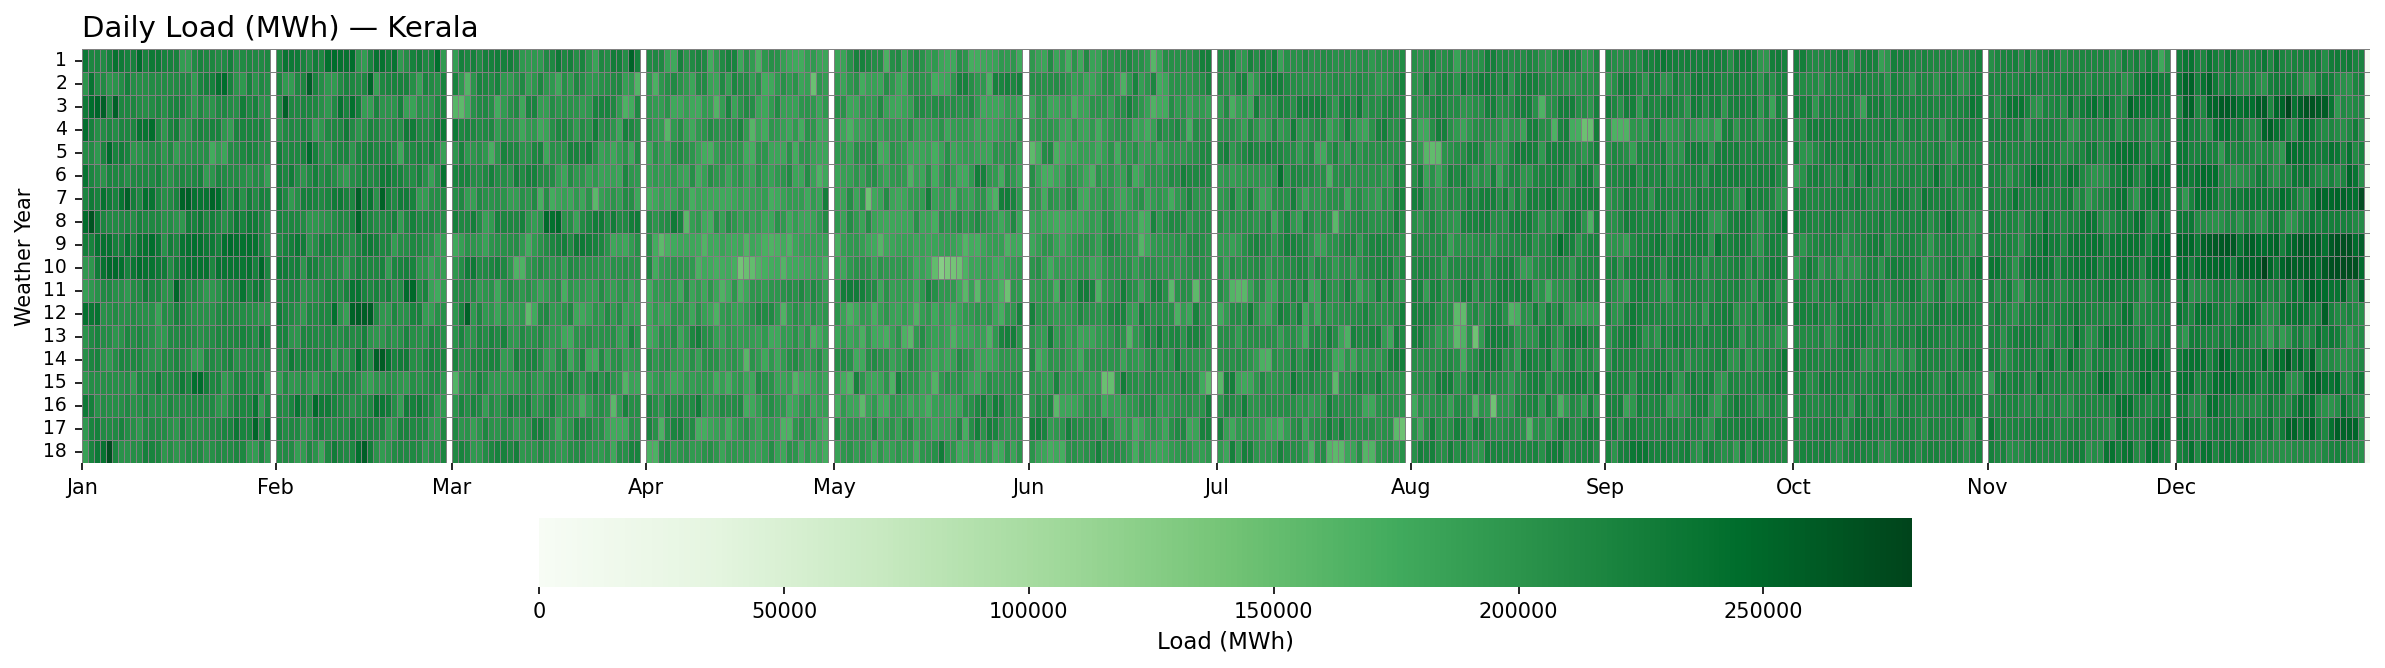

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

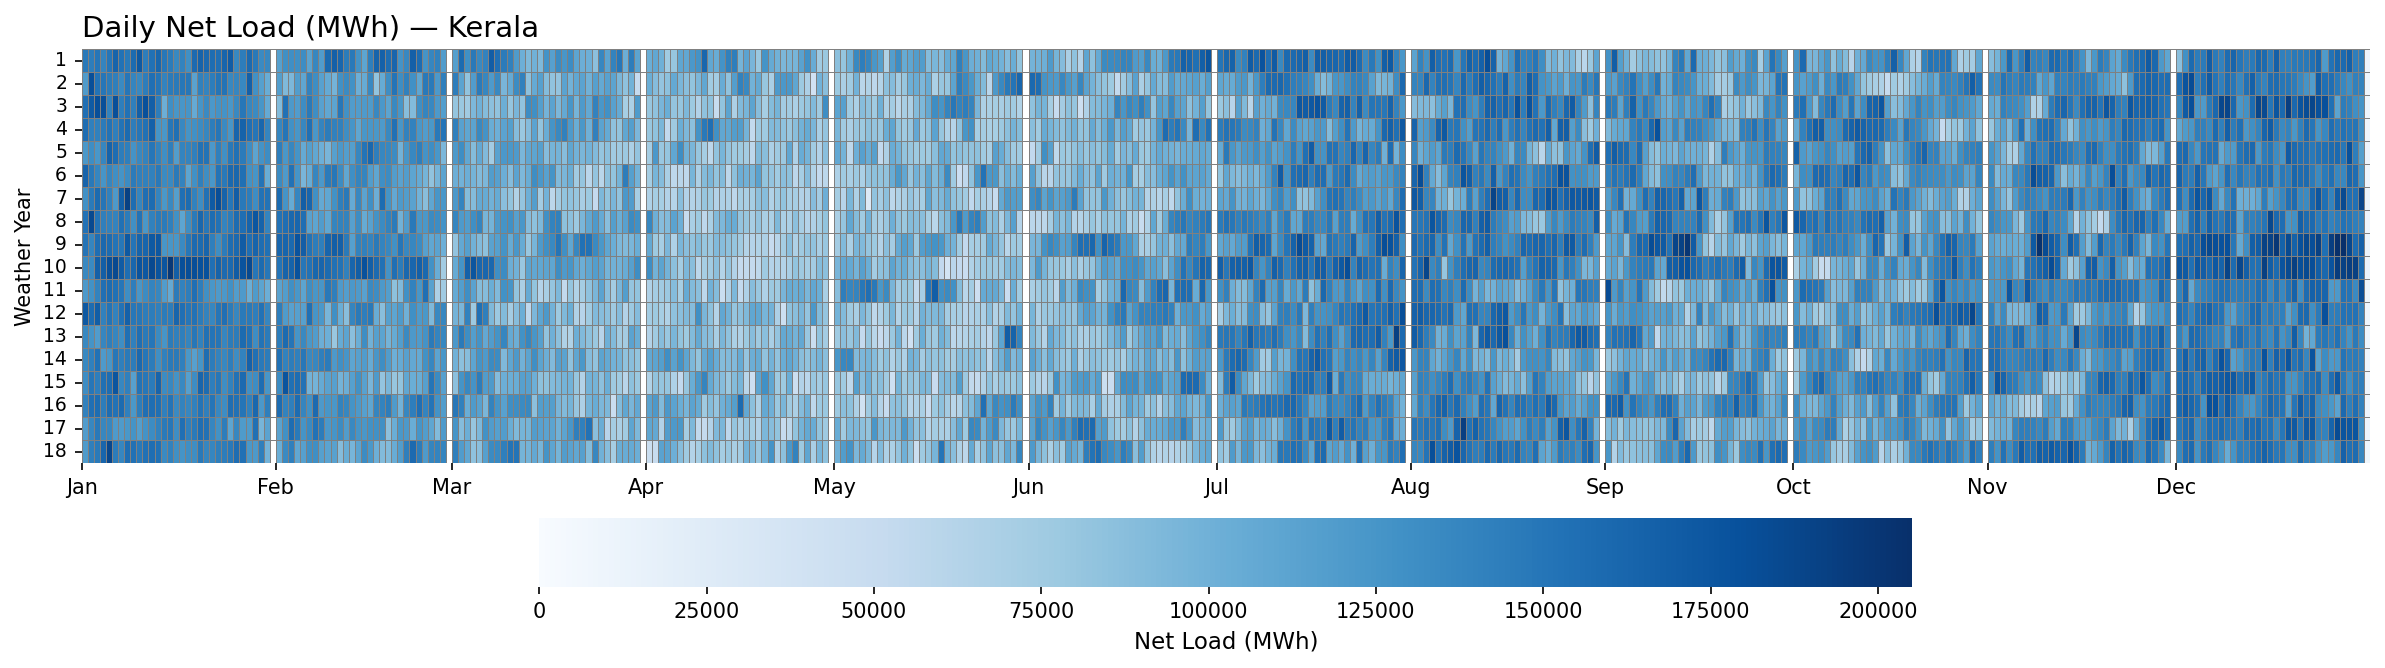

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

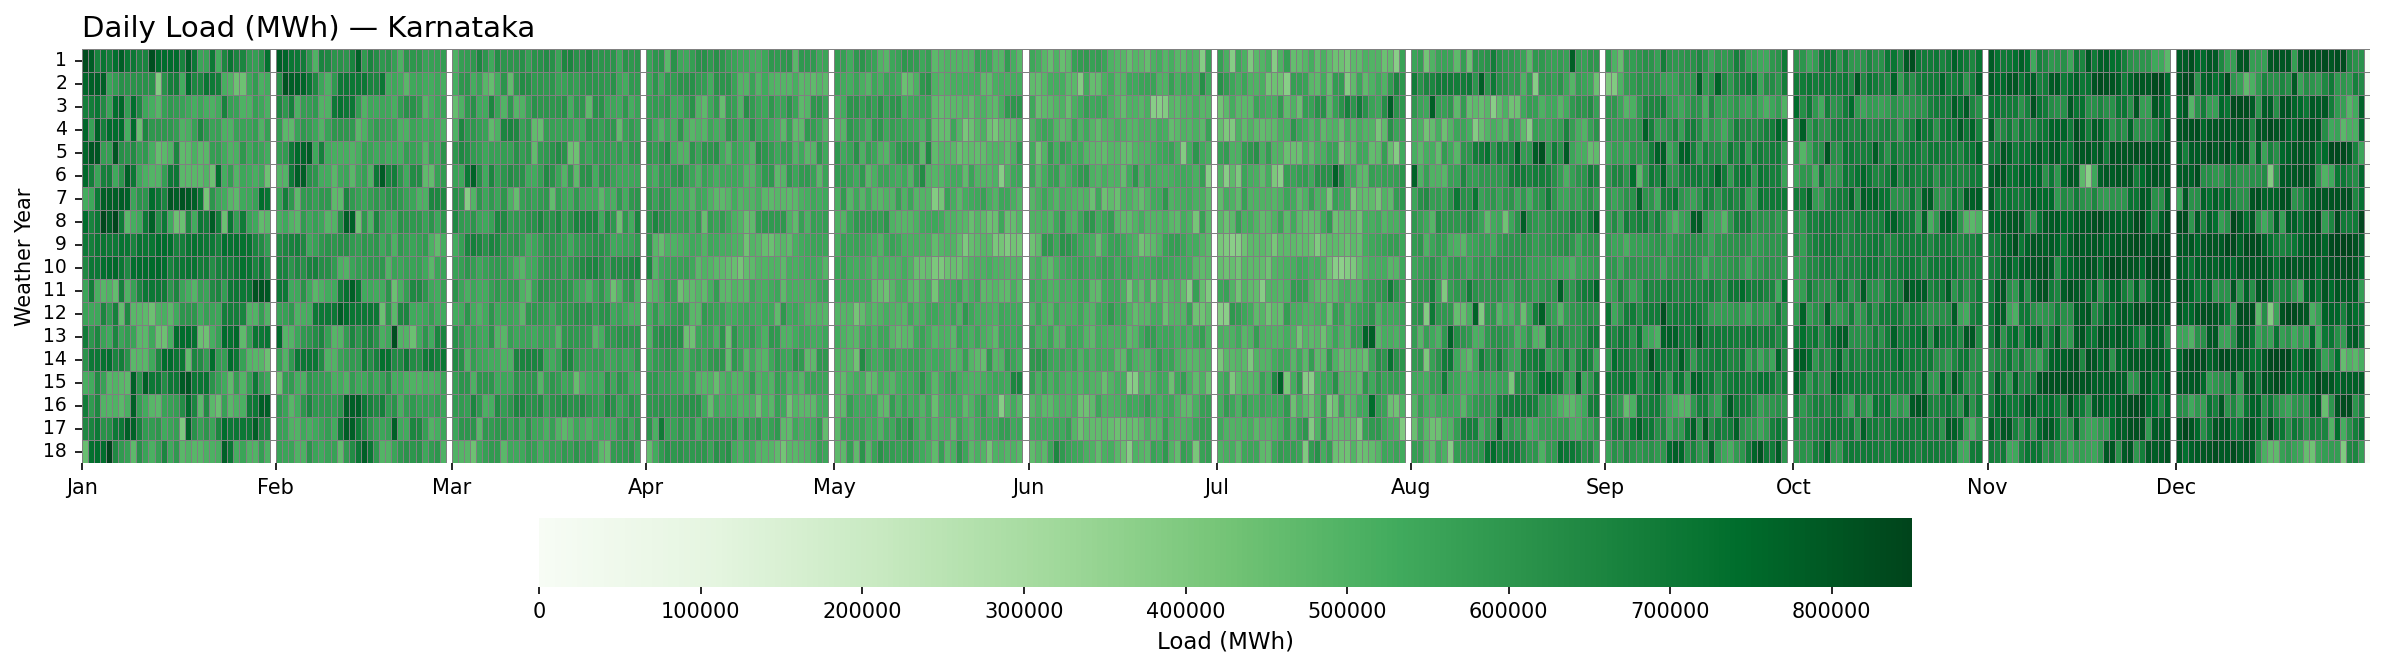

/tmp/ipykernel_721687/4064072831.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

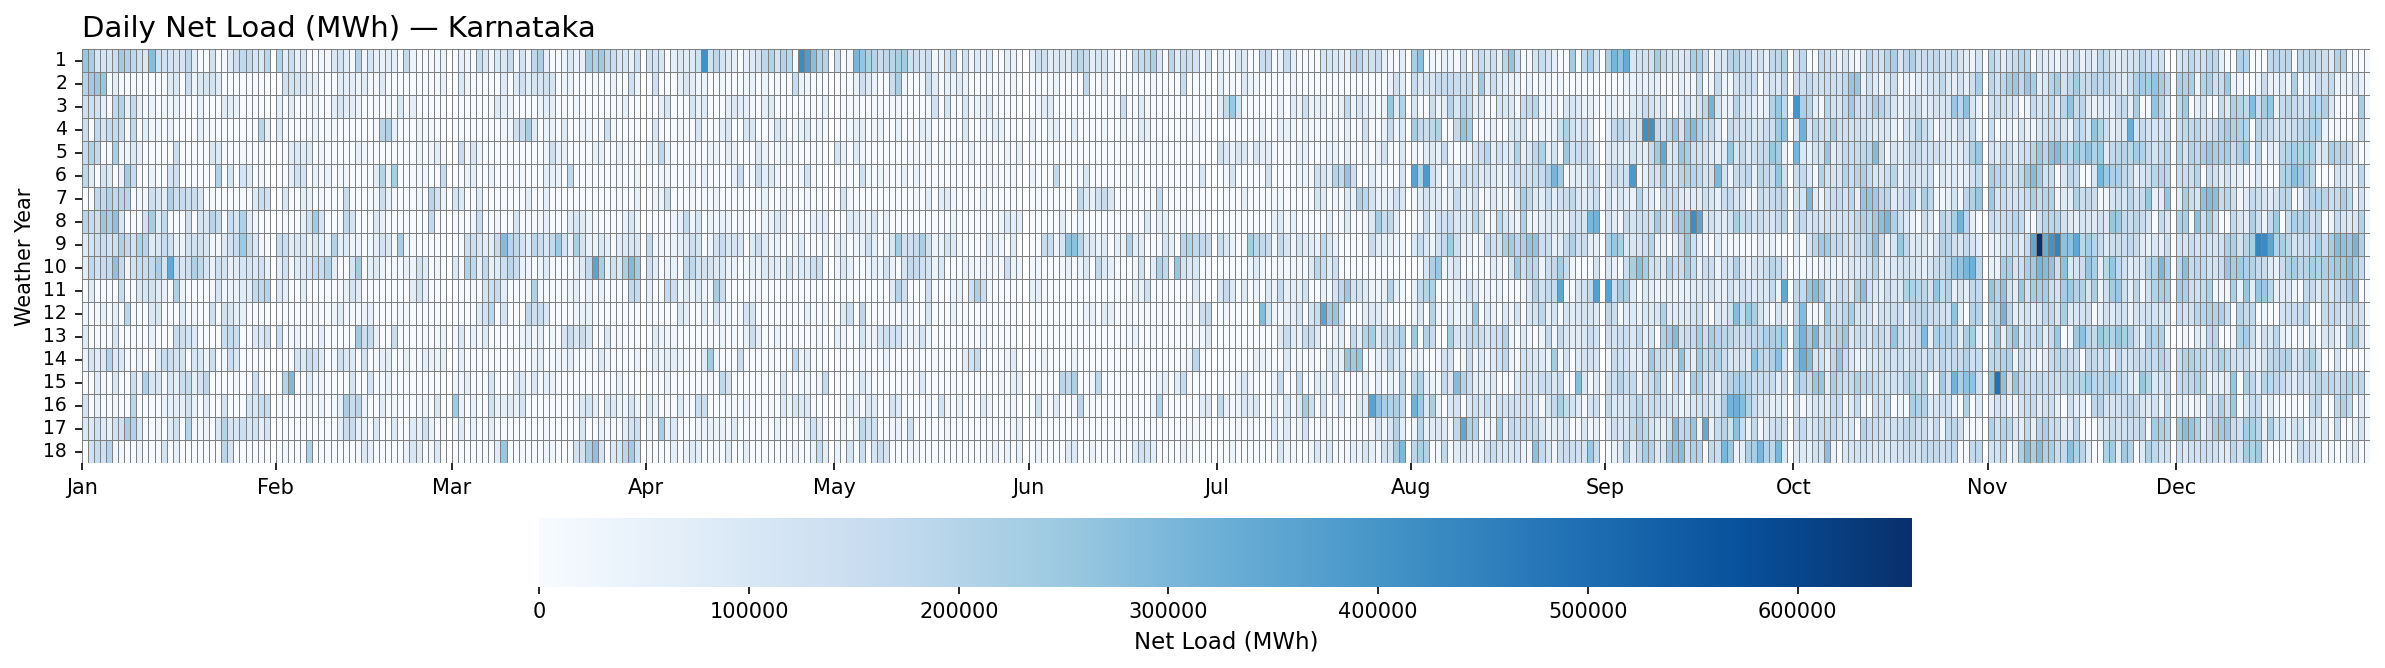

In [35]:
# For Kerala
plot_zone_load_heatmap("Kerala", plf_df, df_load_, df_dispatch_, df_transmission_timepoints_zone, freq="D")
plot_zone_netload_heatmap("Kerala", plf_df, df_load_, df_dispatch_, df_transmission_timepoints_zone, freq="D")

# For Karnataka
plot_zone_load_heatmap("Karnataka", plf_df, df_load_, df_dispatch_, df_transmission_timepoints_zone, freq="D")
plot_zone_netload_heatmap("Karnataka", plf_df, df_load_, df_dispatch_, df_transmission_timepoints_zone, freq="D")

In [36]:
def build_factor_distributions(selected_zone,
                               plf_df,
                               df_load_,
                               df_dispatch_,
                               df_transmission_timepoints_zone,
                               fy=None):
    """
    Build distributions of key factors (LoL ratio, RE CF, Thermal CAF,
    Transmission CF, Peak Net Load, Hydro_Storage CF) on LoL days,
    combining all iterations for a state or National.
    """

    # --- Ensure National rows if needed ---
    if selected_zone == "National":
        plf_df = build_national_plf(plf_df)
        df_load_, df_dispatch_, df_tx_zone = build_national_df(df_load_, df_dispatch_, df_transmission_timepoints_zone)
    else:
        df_tx_zone = df_transmission_timepoints_zone

    # --- Get matrices from LoL builder ---
    iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # --- Flatten to long arrays (drop NaNs) ---
    factors = {
        "LoL ratio %": LoL_ratio_pct.values.flatten(),
        "RE CF %": RE_CF_pct.values.flatten(),
        "Thermal CAF %": CAF_pct.values.flatten(),
        "Tx CF %": TX_pct.values.flatten(),
        "Peak Net Load %": PEAK_pct.values.flatten(),
    }

    # --- Hydro_Storage CF (optional, same style as renewables) ---
    hydro = df_dispatch_[(df_dispatch_['load_zone'] == selected_zone) &
                         (df_dispatch_['technology'].str.contains("Hydro_Storage", case=False, na=False))].copy()
    if not hydro.empty:
        hydro = _ensure_timestamp(hydro, 'timepoint')
        hydro = _norm(hydro)
        daily_cf = (hydro.groupby(['W','H','A','date'], as_index=False)
                           .agg(energy_mwh_day=('power_mw','sum'),
                                cap_hour_sum_day=('capacity_mw','sum')))
        daily_cf['cf'] = np.where(daily_cf['cap_hour_sum_day'] > 0,
                                  daily_cf['energy_mwh_day'] / daily_cf['cap_hour_sum_day'],
                                  np.nan)
        factors["Hydro_Storage CF %"] = (daily_cf['cf'] * 100).dropna().values

    # Drop NaNs for all
    for k in list(factors.keys()):
        factors[k] = pd.Series(factors[k]).dropna().values

    return factors

In [37]:
def plot_factor_distributions(selected_zone,
                              plf_df,
                              df_load_,
                              df_dispatch_,
                              df_transmission_timepoints_zone,
                              fy=None):
    """
    Plot histograms for each factor wrt LoL days (all iterations combined).
    """
    factors = build_factor_distributions(selected_zone,
                                         plf_df,
                                         df_load_,
                                         df_dispatch_,
                                         df_transmission_timepoints_zone,
                                         fy=fy)

    n_factors = len(factors)
    fig, axes = plt.subplots(1, n_factors, figsize=(4*n_factors, 4), dpi=150)

    if n_factors == 1:
        axes = [axes]

    for ax, (name, values) in zip(axes, factors.items()):
        sns.histplot(values, ax=ax, bins=30, kde=True, color="steelblue")
        ax.set_title(f"{name}\n{selected_zone}", fontsize=10)
        ax.set_xlabel(name)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_721687/757495019.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fami

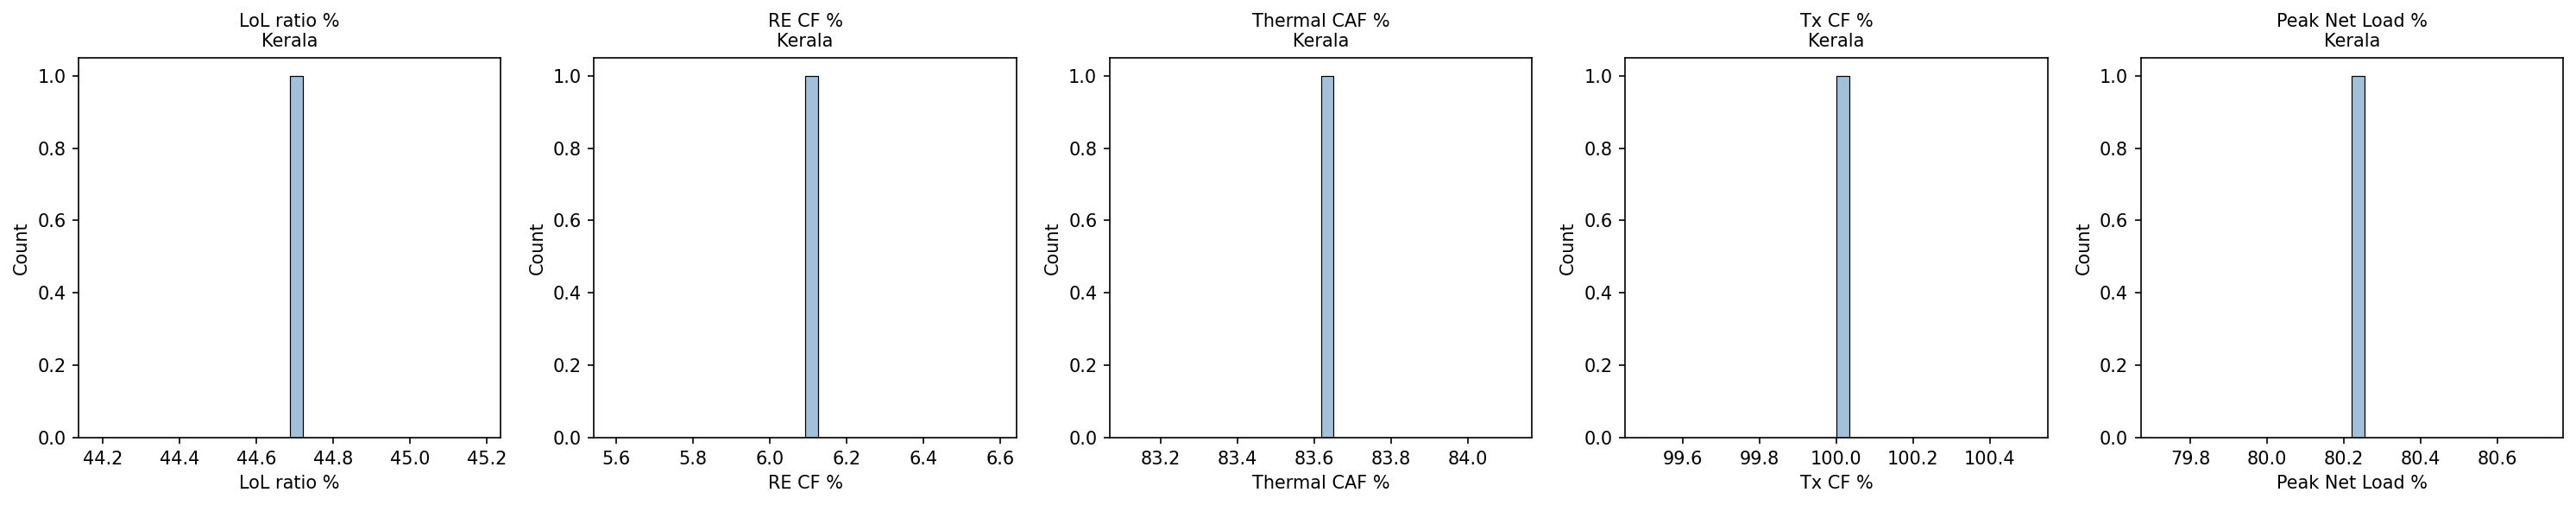

/tmp/ipykernel_721687/757495019.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fami

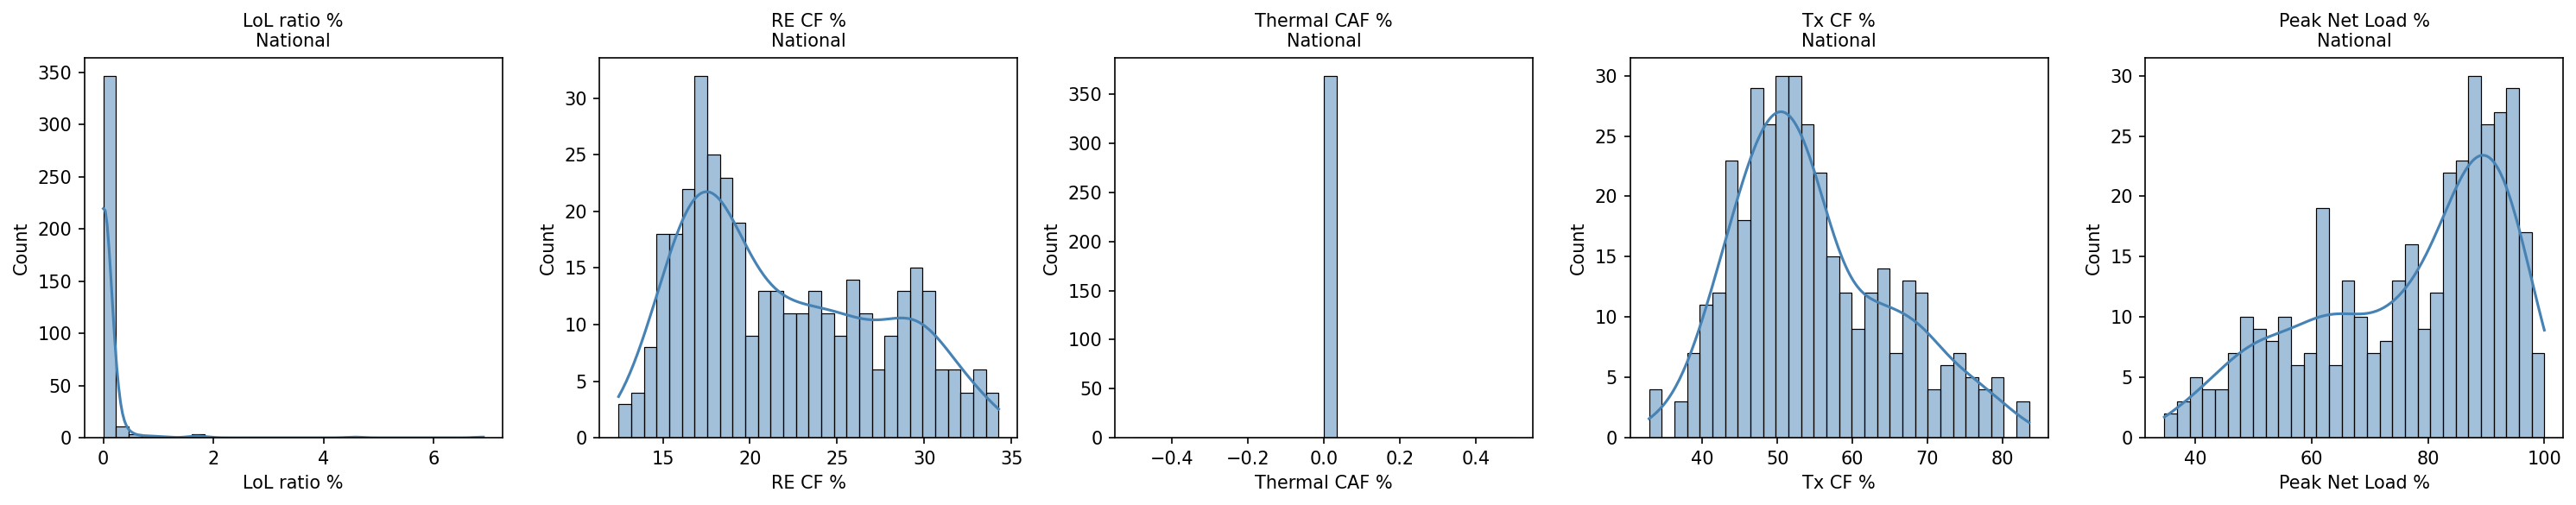

In [38]:
# For a state
plot_factor_distributions("Kerala",
                          plf_df,
                          df_load_,
                          df_dispatch_,
                          df_transmission_timepoints_zone,
                          fy=None)

# For National
plot_factor_distributions("National",
                          plf_df,
                          df_load_,
                          df_dispatch_,
                          df_transmission_timepoints_zone,
                          fy=None)

In [39]:
def build_factor_lol_severity(selected_zone,
                              plf_df,
                              df_load_,
                              df_dispatch_,
                              df_transmission_timepoints_zone,
                              fy=None,
                              bins=30):
    """
    Build severity-weighted distributions wrt LoL for key factors:
    LoL ratio, RE CF, Thermal CAF, Transmission CF,
    Peak Net Load %, Hydro_Storage CF.
    """

    # --- Ensure National if needed ---
    if selected_zone == "National":
        plf_df = build_national_plf(plf_df)
        df_load_, df_dispatch_, df_tx_zone = build_national_df(df_load_, df_dispatch_, df_transmission_timepoints_zone)
    else:
        df_tx_zone = df_transmission_timepoints_zone

    # --- Prep load ---
    df_load_ = _ensure_timestamp(df_load_.copy(), 'timepoint')
    df_load_ = _norm(df_load_)
    df_load_ = _apply_fy(df_load_, fy)

    # Focus only on hours with LoL
    df_lol = df_load_[df_load_['unserved_energy'] > 0].copy()
    if df_lol.empty:
        print(f"No LoL hours for {selected_zone}")
        return {}

    # --- Factor 1: LoL ratio % ---
    df_lol['lol_ratio_pct'] = 100 * df_lol['unserved_energy'] / df_lol['static_load']

    # --- Prep dispatch ---
    df_dispatch_ = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    df_dispatch_ = _norm(df_dispatch_)

    # --- Factor 2: RE CF % (Wind+Solar) ---
    ws = df_dispatch_[(df_dispatch_['load_zone'] == selected_zone) &
                      (df_dispatch_['technology'].isin(['Wind','Solar']))].copy()
    if not ws.empty:
        re_hr = ws.groupby(['timestamp','W','H','A'], as_index=False).agg(
            power_mw=('power_mw','sum'), capacity_mw=('capacity_mw','sum'))
        re_hr['cf'] = np.where(re_hr['capacity_mw'] > 0, re_hr['power_mw']/re_hr['capacity_mw'], np.nan)
        df_lol = df_lol.merge(re_hr[['timestamp','W','H','A','cf']],
                              on=['timestamp','W','H','A'], how='left')
        df_lol['re_cf_pct'] = df_lol['cf'] * 100
    else:
        df_lol['re_cf_pct'] = np.nan

    # --- Factor 3: Thermal CAF % (capacity-weighted availability) ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = df_dispatch_[(df_dispatch_['load_zone']==selected_zone) &
                      (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False))].copy()
    if not td.empty:
        td['af_src'] = _infer_availability_series(td)
        caf_ts = (td.assign(weighted=td['capacity_mw']*td['af_src'])
                    .groupby(['timestamp','W','H','A'], as_index=False)
                    .agg(caf_num=('weighted','sum'),
                         caf_den=('capacity_mw','sum')))
        caf_ts['caf'] = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
        df_lol = df_lol.merge(caf_ts[['timestamp','W','H','A','caf']],
                              on=['timestamp','W','H','A'], how='left')
        df_lol['thermal_caf_pct'] = df_lol['caf'] * 100
    else:
        df_lol['thermal_caf_pct'] = np.nan

    # --- Factor 4: Transmission CF % ---
    tx = df_tx_zone[df_tx_zone['load_zone']==selected_zone].copy()
    if not tx.empty:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        df_lol = df_lol.merge(tx[['timestamp','W','H','A','tx_cap_factor']],
                              on=['timestamp','W','H','A'], how='left')
        df_lol['tx_cf_pct'] = df_lol['tx_cap_factor'] * 100
    else:
        df_lol['tx_cf_pct'] = np.nan

    # --- Factor 5: Peak Net Load % ---
    # Hourly net load = load - (wind+solar)
    if not ws.empty:
        re_hr = re_hr[['timestamp','W','H','A','power_mw']].rename(columns={'power_mw':'re_mw'})
        nl = df_load_.merge(re_hr, on=['timestamp','W','H','A'], how='left')
        nl['re_mw'] = nl['re_mw'].fillna(0.0)
        nl['net_load_mw'] = nl['static_load'] - nl['re_mw']

        # Annual peak per iteration
        annual_pk = nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max().rename(
            columns={'net_load_mw':'annual_peak_net_load_mw'})
        nl = nl.merge(annual_pk, on=['W','H','A'], how='left')
        nl['peak_pct'] = 100 * nl['net_load_mw'] / nl['annual_peak_net_load_mw']
        df_lol = df_lol.merge(nl[['timestamp','W','H','A','peak_pct']],
                              on=['timestamp','W','H','A'], how='left')
        df_lol['peak_netload_pct'] = df_lol['peak_pct']
    else:
        df_lol['peak_netload_pct'] = np.nan

    # --- Factor 6: Hydro_Storage CF % ---
    hydro = df_dispatch_[(df_dispatch_['load_zone']==selected_zone) &
                         (df_dispatch_['technology'].str.contains("Hydro_Storage", case=False, na=False))].copy()
    if not hydro.empty:
        daily_cf = (hydro.groupby(['W','H','A','timestamp'], as_index=False)
                          .agg(power_mw=('power_mw','sum'),
                               capacity_mw=('capacity_mw','sum')))
        daily_cf['cf'] = np.where(daily_cf['capacity_mw']>0,
                                  daily_cf['power_mw']/daily_cf['capacity_mw'],
                                  np.nan)
        df_lol = df_lol.merge(daily_cf[['timestamp','W','H','A','cf']],
                              on=['timestamp','W','H','A'], how='left', suffixes=('','_hydro'))
        df_lol['hydro_storage_cf_pct'] = df_lol['cf']*100
    else:
        df_lol['hydro_storage_cf_pct'] = np.nan

    # --- Build severity-weighted distributions ---
    factors = {}
    for col, label in [
        ('lol_ratio_pct','LoL ratio %'),
        ('re_cf_pct','RE CF %'),
        ('thermal_caf_pct','Thermal CAF %'),
        ('tx_cf_pct','Tx CF %'),
        ('peak_netload_pct','Peak Net Load %'),
        ('hydro_storage_cf_pct','Hydro_Storage CF %'),
    ]:
        if col not in df_lol: 
            continue
        values = df_lol[col].dropna()
        sev    = df_lol.loc[values.index,'unserved_energy']
        if values.empty: 
            continue
        hist, bin_edges = np.histogram(values, bins=bins, weights=sev)
        factors[label] = (bin_edges, hist)

    return factors

In [40]:
def plot_factor_lol_severity(selected_zone,
                             plf_df,
                             df_load_,
                             df_dispatch_,
                             df_transmission_timepoints_zone,
                             fy=None,
                             bins=30):
    """Plot severity-weighted distributions of factors wrt LoL days."""
    factors = build_factor_lol_severity(selected_zone,
                                        plf_df,
                                        df_load_,
                                        df_dispatch_,
                                        df_transmission_timepoints_zone,
                                        fy=fy,
                                        bins=bins)

    n_factors = len(factors)
    fig, axes = plt.subplots(1, n_factors, figsize=(4*n_factors,4), dpi=150)

    if n_factors == 1:
        axes = [axes]

    for ax, (name, (bin_edges, hist)) in zip(axes, factors.items()):
        centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.bar(centers, hist, width=np.diff(bin_edges),
               align='center', alpha=0.7, color="firebrick")
        ax.set_title(f"{name}\n{selected_zone}", fontsize=10)
        ax.set_xlabel(name)
        ax.set_ylabel("LoL Severity (MWh unserved)")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_721687/867417417.py:55: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False))].copy()
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findf

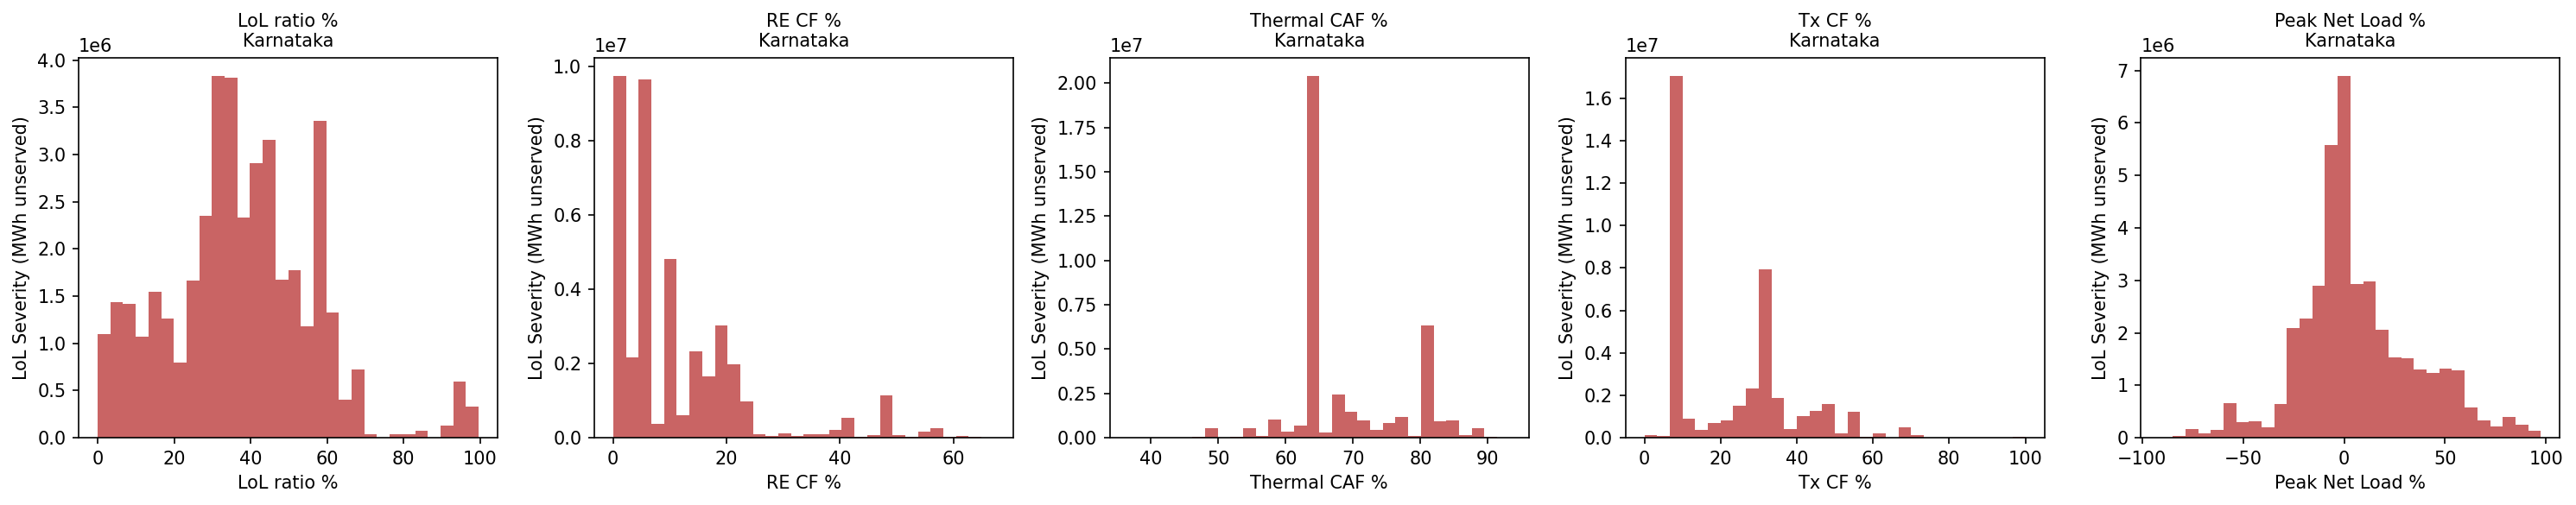

/tmp/ipykernel_721687/867417417.py:55: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False))].copy()
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findf

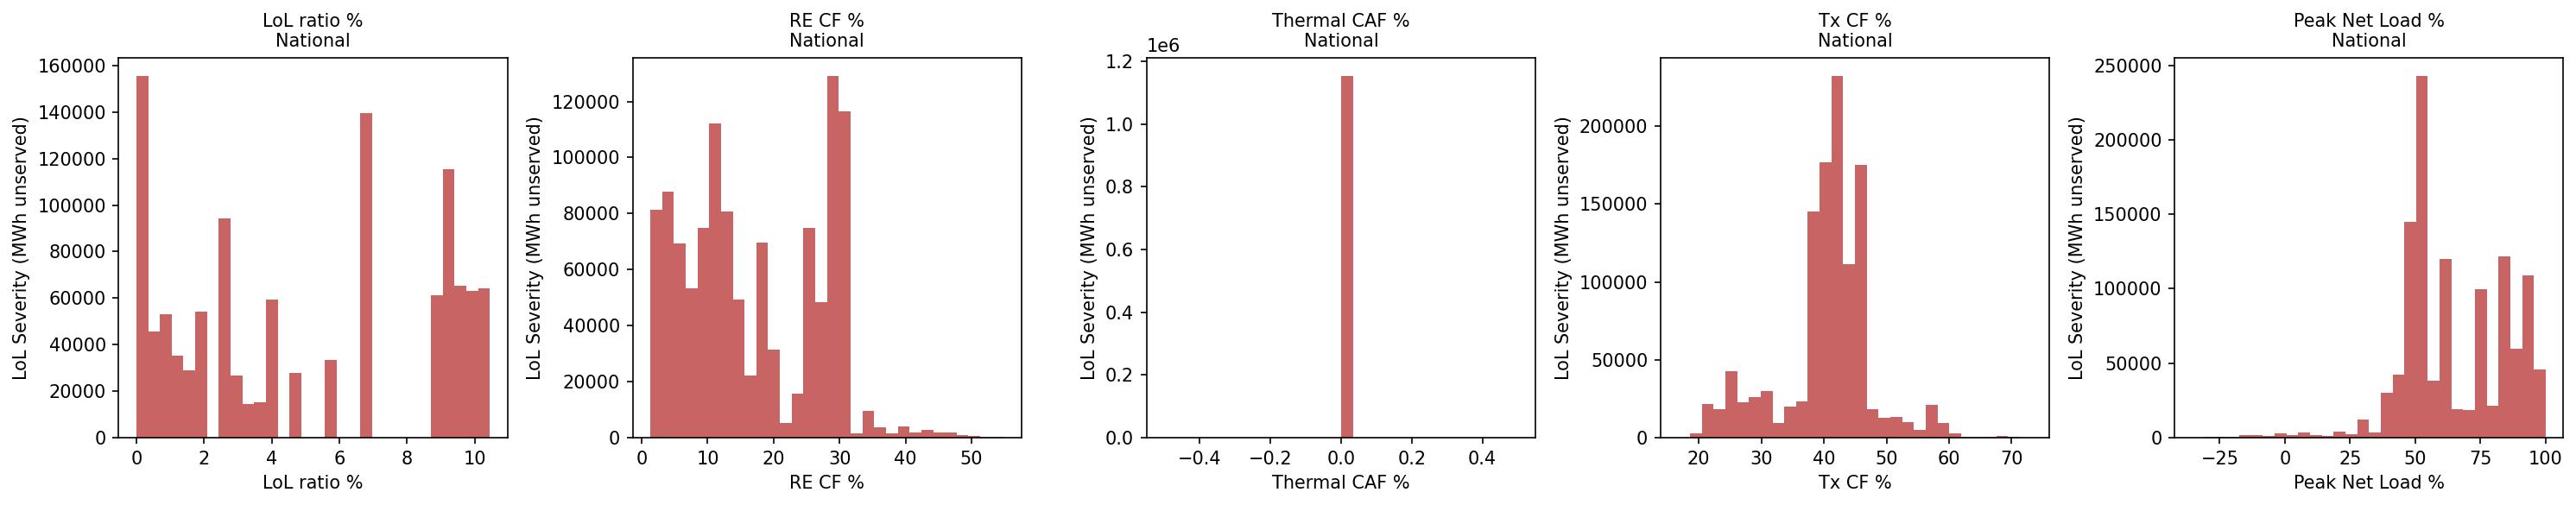

In [41]:
# For a state
plot_factor_lol_severity("Karnataka",
                         plf_df,
                         df_load_,
                         df_dispatch_,
                         df_transmission_timepoints_zone,
                         fy=None)

# For National
plot_factor_lol_severity("National",
                         plf_df,
                         df_load_,
                         df_dispatch_,
                         df_transmission_timepoints_zone,
                         fy=None)